# CLIMB — figure notebook

**Does unsupervised (MLM) pretraining on SMILES help a chemical language model, or can you skip it?**

Every figure in the paper is produced here, from the collected experiment data in `figure_data/`
(synced from `s3://climb-s3-bucket/experiments/`). §1 fixes fonts, colours and the save routine
once, so every panel is identically formatted; each figure is defined in exactly **one** cell and
exported to `figures_out/` as both PNG and PDF.

### Regime vocabulary (identical in every figure)
| term | meaning |
|---|---|
| **random** | chance model — 0.5 ROC-AUC / predict-the-mean RMSE. A reference *line*, never a bar. |
| **no_pretrain** | random-init ModernBERT, no pretraining, **frozen** features → head trained on the eval task. |
| **unsup_only** | MLM pretraining only, frozen features. |
| **sup_only** | random init → supervised fine-tune, no MLM (one arm per SFT recipe; on-disk dirs are still named `skip_*`). |
| **unsup→sup** | MLM, then supervised fine-tune — the realistic recipe. |

### The eight figures
| ID | Question it answers | Data |
|---|---|---|
| **A1** | Which model performs best across datasets? (tough held-out-scaffold split) | real |
| **A2** | How does pretraining scale in forward passes? | real (+ marked pending region) |
| **B1p1** | Does pretraining help small datasets more, and through which mechanism? | real |
| **E1** | With end-to-end deployment instead of a frozen probe, does pretraining pay off? | real |
| **B2** | If we pretrain on a *garbled* objective, do the benefits survive? | real once E13 lands, else marked placeholder |
| **C1J1** | Which SFT label type helps most, how much lift over `no_pretrain`, and does transfer track chemistry? | real |
| **I1** | Do corpus-similar or novel molecules benefit most from pretraining? | real |
| **H1** | Does SMILES enumeration beat canonical repetition? | real |

**Protocol matching.** Every panel compares arms evaluated the *same* way. A1/A2/B2/C1J1/H1 use the
single DeepChem scaffold hold-out; B1p1 uses the label-efficiency sweep; I1 needs per-molecule
predictions and so uses the 5-fold CV predictions for all of its arms. No panel mixes schemes.

## 1 · Global style — set once, applied to every figure

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
from pathlib import Path

STYLE = dict(
    font_family="sans-serif", font_stack=["Arial","Helvetica","DejaVu Sans"],
    serif_stack=["Times New Roman","Nimbus Roman","DejaVu Serif"],
    fs_base=8, fs_axis_label=9, fs_title=9, fs_legend=7.5, fs_annot=7, fs_panel_tag=11,
    col1=3.50, col15=4.75, col2=7.20,
    lw=1.4, lw_thin=0.8, marker_size=5.0, cap_size=2.5, grid_alpha=0.30,
    dpi_screen=120, dpi_save=300, save_formats=("png","pdf"), outdir="figures_out",
)
def _install_rcparams(style=STYLE):
    fam=style["font_family"]; stack=style["font_stack"] if fam=="sans-serif" else style["serif_stack"]
    mpl.rcParams.update({
        "figure.dpi":style["dpi_screen"],"savefig.dpi":style["dpi_save"],
        "figure.facecolor":"white","savefig.facecolor":"white","savefig.bbox":"tight","savefig.pad_inches":0.03,
        "pdf.fonttype":42,"ps.fonttype":42,
        "font.family":fam,("font.sans-serif" if fam=="sans-serif" else "font.serif"):stack,
        "font.size":style["fs_base"],"axes.titlesize":style["fs_title"],"axes.labelsize":style["fs_axis_label"],
        "xtick.labelsize":style["fs_base"],"ytick.labelsize":style["fs_base"],"legend.fontsize":style["fs_legend"],
        "mathtext.default":"regular","axes.spines.top":False,"axes.spines.right":False,
        "axes.linewidth":0.8,"axes.edgecolor":"#333333","axes.labelcolor":"#111111",
        "axes.titlepad":4.0,"axes.titleweight":"bold",
        "xtick.direction":"out","ytick.direction":"out",
        "xtick.major.size":3.0,"ytick.major.size":3.0,"xtick.minor.size":1.6,"ytick.minor.size":1.6,
        "xtick.major.width":0.8,"ytick.major.width":0.8,"xtick.minor.width":0.6,"ytick.minor.width":0.6,
        "xtick.color":"#333333","ytick.color":"#333333","xtick.minor.visible":True,"ytick.minor.visible":True,
        "lines.linewidth":style["lw"],"lines.markersize":style["marker_size"],"lines.markeredgewidth":0.6,
        "axes.grid":True,"grid.color":"#B0B0B0","grid.linewidth":0.5,"grid.alpha":style["grid_alpha"],
        "axes.axisbelow":True,"legend.frameon":False,"legend.handlelength":1.4,
        "legend.columnspacing":1.0,"legend.labelspacing":0.35,
    })
_install_rcparams(); Path(STYLE["outdir"]).mkdir(exist_ok=True)
print("matplotlib",mpl.__version__,"| font ->",
      font_manager.FontProperties(family=mpl.rcParams["font.family"]).get_name(),
      "| out:",STYLE["outdir"])

matplotlib 3.9.4 | font -> Arial | out: figures_out


In [2]:
# ---- palette, regime registry, task registry: the single source of truth for colour + label ----
# Every figure reads colours from here, so a model has the same colour in A1, A2, B1p1 and B2 and
# the legend transfers between panels without the reader re-learning it.
PALETTE = dict(grey="#8A8A8A", grey2="#C4C4C4", black="#1A1A1A", blue="#4477AA", green="#228833",
               orange="#EE7733", red="#CC3311", teal="#009988", purple="#AA3377", cyan="#66CCEE",
               yellow="#CCBB44", sand="#DDCC77")

sup_recipes = ["dense","sparse_all","dense_plus_sparse","minimol_full","mixed"]
_recipe_pretty = {"dense":"dense (MTR)","sparse_all":"sparse_all","dense_plus_sparse":"dense+sparse",
                  "minimol_full":"minimol_full","mixed":"mixed"}
_recipe_color  = {"dense":PALETTE["orange"],"sparse_all":PALETTE["teal"],"dense_plus_sparse":PALETTE["red"],
                  "minimol_full":PALETTE["purple"],"mixed":PALETTE["cyan"]}
_recipe_marker = {"dense":"^","sparse_all":"v","dense_plus_sparse":"P","minimol_full":"X","mixed":"<"}

REGIME = {  # key : (colour, marker, linestyle, label)
    "random"      :(PALETTE["grey2"], None,(0,(1,1)),  "random (chance)"),
    "no_pretrain" :(PALETTE["grey"],  "o", (0,(3,2)),  "no_pretrain (frozen)"),
    "ecfp4"       :(PALETTE["black"], "D", (0,(4,1)),  "Morgan+XGBoost (ECFP4)"),
    "fp_desc"     :(PALETTE["sand"],  "s", (0,(4,1)),  "Morgan+desc+XGBoost"),
    "unsup_only"  :(PALETTE["blue"],  "o", "-",        "unsup_only (MLM)"),
    "unsup2sup"   :(PALETTE["green"], "s", "-",        "unsup→sup (MLM→SFT)"),
}
for r in sup_recipes:
    REGIME[f"sup_only:{r}"]=(_recipe_color[r],_recipe_marker[r],"-",f"sup_only: {_recipe_pretty[r]}")
rc_color=lambda k:REGIME[k][0]; rc_marker=lambda k:REGIME[k][1]
rc_ls   =lambda k:REGIME[k][2]; rc_label =lambda k:REGIME[k][3]

TASKS = {
    "ESOL"          :dict(metric="RMSE",   higher_better=False,pretty="ESOL", domain="solubility"),
    "BBBP"          :dict(metric="ROC-AUC",higher_better=True, pretty="BBBP", domain="ADMET"),
    "BACE"          :dict(metric="ROC-AUC",higher_better=True, pretty="BACE", domain="binding"),
    "Tox21"         :dict(metric="ROC-AUC",higher_better=True, pretty="Tox21",domain="toxicity"),
    "QM7"           :dict(metric="RMSE",   higher_better=False,pretty="QM7",  domain="quantum"),
    # HIV is scored by NEF1% (top-1% early enrichment) -- the virtual-screening readout. Chance is
    # the active fraction (1443/41120), not 0.5.
    "HIV"           :dict(metric="NEF1%",  higher_better=True, pretty="HIV",  domain="virtual screening",
                          suite_key="HIV_nef1", chance=0.0351),
    "Lipophilicity" :dict(metric="RMSE",   higher_better=False,pretty="Lipo.",domain="ADMET"),
}
CORE_TASKS=["ESOL","BBBP","BACE","Tox21","QM7","HIV"]
BUDGET_FP={"2M":2e6,"8M":8e6,"24M":24e6,"48M":48e6,"96M":96e6}
MATCHED_BUDGET="8M"          # largest budget where every arm ran to completion
U2S_SFT_FP=2e6               # unsup->sup spends its MLM base PLUS a 2M-FP SFT stage

def chance_value(task):
    return TASKS[task].get("chance", 0.5 if TASKS[task]["higher_better"] else 1.0)
def mlabel(task):
    m=TASKS[task]; return f'{m["metric"]} {"↑" if m["higher_better"] else "↓"}'
def ttitle(task,oneline=False):
    sep=" " if oneline else "\n"; return f'{TASKS[task]["pretty"]}{sep}({mlabel(task)})'
def lift(value,task,floor):
    """Improvement over the no_pretrain floor; positive = better for BOTH metric directions."""
    if not np.isfinite(floor) or floor==0 or not np.isfinite(value): return np.nan
    return (value-floor)/floor if TASKS[task]["higher_better"] else (floor-value)/floor

# ---- shared drawing helpers ----
def set_fp_axis(ax,budgets):
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(ticker.FixedLocator(list(budgets)))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter([f"{int(b/1e6)}M" for b in budgets]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
def label_all_yticks(ax,n=5):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n)); ax.yaxis.set_minor_locator(ticker.NullLocator())
def panel_tag(ax,tag,dx=-0.12,dy=1.02):
    ax.text(dx,dy,tag,transform=ax.transAxes,fontsize=STYLE["fs_panel_tag"],fontweight="bold",va="bottom",ha="right")
def add_chance_line(ax,task):
    ax.axhline(chance_value(task),color="#999999",ls=(0,(1,1.5)),lw=1.0,zorder=5)
def no_data_watermark(ax,need):
    ax.text(0.5,0.5,f"NO DATA\n{need}",transform=ax.transAxes,ha="center",va="center",
            fontsize=STYLE["fs_annot"]+1,color="#B00020",fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4",fc="#FCE8E8",ec="#B00020",lw=0.8),zorder=5)
    for s in ax.spines.values(): s.set_linestyle((0,(3,3)))
def save_fig(fig,name):
    for ext in STYLE["save_formats"]: fig.savefig(f'{STYLE["outdir"]}/{name}.{ext}')
    print("saved",name)

import numpy as np
print("registry ready:",len(REGIME),"regimes,",len(TASKS),"tasks")

registry ready: 11 regimes, 7 tasks


## 2 · Load the experiment data

One tidy table per evaluation scheme. **Completion is derived**, never assumed: a run enters the
figures only if `verified.json` exists or its achieved forward passes reach ≥98 % of budget.
Missing evidence is reported as `unknown` and printed loudly rather than treated as fine — a
hand-maintained blocklist cannot catch a *newly* truncated run, which is exactly how half-trained
models reached plots before.

In [3]:
import json, re, glob, os
import numpy as np, pandas as pd
DATA_ROOT=Path("figure_data")

def _achieved_fp(run_dir):
    """Last forward_passes_seen in metrics.jsonl; None if unavailable."""
    m=run_dir/"metrics.jsonl"
    if not m.exists(): return None
    last=""
    try:
        with m.open() as fh:
            for line in fh:
                if line.strip(): last=line
    except OSError: return None
    try: return float(json.loads(last).get("forward_passes_seen",0) or 0)
    except Exception: return None

def run_completion(run_dir,budget_fp,tol=0.98):
    """-> (status, achieved_fp); status in {complete, truncated, unknown, n/a}."""
    if (run_dir/"verified.json").exists(): return "complete",budget_fp
    # Anchors and random baselines have no forward-pass budget, so nothing could be truncated.
    # Flagging them would train the reader to ignore the warning, defeating its purpose.
    if not np.isfinite(budget_fp) or not budget_fp: return "n/a",np.nan
    fp=_achieved_fp(run_dir)
    if fp is None: return "unknown",np.nan
    return ("complete" if fp>=tol*budget_fp else "truncated"),fp

_UNKNOWN_RUNS=set()

def load_suite(run_dir,sub="moleculenet"):
    p=run_dir/sub/"suite_summary.json"
    if not p.exists(): return None
    d=json.loads(p.read_text()); out={}
    for k,v in d.items():
        if k.endswith("_MEAN"): out[(k[:-5],"mean")]=v
        elif k.endswith("_STD"): out[(k[:-4],"std")]=v
    return out

def _eval_mtime(run_dir,sub):
    """When this run's summary was written. Re-scoring the SAME encoder with the current eval_v2
    moves metrics by up to ~0.03 (head-seed noise plus code drift), so a panel that mixes an old
    summary with a fresh one is comparing two protocols. Carrying the timestamp makes that
    detectable instead of invisible."""
    p=run_dir/sub/"suite_summary.json"
    return pd.Timestamp(p.stat().st_mtime,unit="s") if p.exists() else pd.NaT

def parse_run(name):
    """Directory name -> regime/recipe/budget/seed, or None if it is not a plottable run."""
    # Pretraining-seed replicates are "<base>_s1"/"_s2". Parse the base and carry the seed, so
    # replicates aggregate instead of being silently dropped.
    m=re.match(r"(.+)_s(\d+)$",name)
    if m:
        base=parse_run(m.group(1))
        return {**base,"seed":int(m.group(2))} if base else None
    if name=="ecfp4_anchor":   return dict(seed=0,regime="ecfp4",  recipe=None,budget_label=None,budget_fp=np.nan)
    if name=="fp_desc_anchor": return dict(seed=0,regime="fp_desc",recipe=None,budget_label=None,budget_fp=np.nan)
    if name.startswith("random_baseline"):
        return dict(seed=0,regime="no_pretrain",recipe=None,budget_label=None,budget_fp=np.nan)
    if name.startswith("corrupt_"):
        m=re.match(r"corrupt_(mlm|mtr)_(\d+M)$",name)
        if m: return dict(seed=0,regime=f"corrupt_{m[1]}",recipe=None,budget_label=m[2],budget_fp=BUDGET_FP[m[2]])
        return None
    m=re.match(r"unsup_(\d+M)$",name)
    if m: return dict(seed=0,regime="unsup_only",recipe=None,budget_label=m[1],budget_fp=BUDGET_FP[m[1]])
    m=re.match(r"skip_(.+)_(\d+M)$",name)      # dir names still 'skip_*'; the regime is sup_only
    if m: return dict(seed=0,regime="sup_only",recipe=m[1],budget_label=m[2],budget_fp=BUDGET_FP[m[2]])
    # unsup->sup: MLM base of <budget> FP, then a 2M-FP SFT stage. budget_label keys off the BASE
    # so it lines up with the same-budget arms; budget_fp is the TRUE total, so the compute axis
    # in A2 is not flattering to this arm.
    m=re.match(r"u2s_(.+)_from(\d+M)$",name)
    if m: return dict(seed=0,regime="unsup2sup",recipe=m[1],budget_label=m[2],
                      budget_fp=BUDGET_FP[m[2]]+U2S_SFT_FP)
    return None

def build_table(sub):
    rows=[]
    for wave in ["climb_v2_phase2","climb_v2_headline"]:
        for rd in sorted((DATA_ROOT/wave).glob("*/")):
            meta=parse_run(rd.name)
            if meta is None: continue
            suite=load_suite(rd,sub=sub)
            if not suite: continue
            st,fp=run_completion(rd,meta["budget_fp"])
            if st=="unknown": _UNKNOWN_RUNS.add(rd.name)
            for task in TASKS:
                sk=TASKS[task].get("suite_key",task)
                if (sk,"mean") in suite:
                    rows.append(dict(wave=wave,run=rd.name,task=task,value=suite[(sk,"mean")],
                                     std=suite.get((sk,"std"),np.nan),truncated=(st=="truncated"),
                                     evaluated_at=_eval_mtime(rd,sub),
                                     achieved_fp=(fp if np.isfinite(fp) else meta["budget_fp"]),**meta))
    return pd.DataFrame(rows)

# DEFAULT for every bar/ladder figure: the single DeepChem scaffold hold-out. It puts the RAREST
# scaffolds in test and therefore actually discriminates; the balanced 5-fold CV saturates (a
# random encoder reaches 0.937 on BBBP vs ~0.70 published) and compresses regime gaps 2-3x.
DF    = build_table("moleculenet")
DF_CV = build_table("moleculenet_cv")     # used only where per-fold predictions are needed (I1)

print(f"single-split: {len(DF):5d} rows / {DF.run.nunique()} runs")
print(f"5-fold CV   : {len(DF_CV):5d} rows / {DF_CV.run.nunique()} runs")
trunc=sorted(DF[DF.truncated].run.unique())
if trunc:
    print(f"\nTRUNCATED, excluded from every figure ({len(trunc)}) - derived from achieved FP:")
    for r in trunc:
        row=DF[DF.run==r].iloc[0]
        print(f"   {r:32s} {row.achieved_fp/1e6:5.1f}M / {row.budget_fp/1e6:.0f}M "
              f"({100*row.achieved_fp/row.budget_fp:.0f}%)")
if _UNKNOWN_RUNS:
    print(f"\n⚠ UNKNOWN COMPLETENESS ({len(_UNKNOWN_RUNS)} runs): no verified.json and no metrics.jsonl.")
    print("  Plotted on trust. 'No evidence' is not 'fine'. Sync evidence with:")
    print("    aws s3 sync s3://climb-s3-bucket/experiments/<wave> figure_data/<wave> \\")
    print("      --exclude '*' --include '*/verified.json' --include '*/metrics.jsonl'")
    for r in sorted(_UNKNOWN_RUNS)[:10]: print(f"    - {r}")

# ---- evaluation-protocol audit ------------------------------------------------------------
# Every arm inside one panel must have been scored by the same eval code. Runs scored more than a
# few days apart may not have been.
for _name,_d in (("single-split",DF),("5-fold CV",DF_CV)):
    _t=_d.dropna(subset=["evaluated_at"]).evaluated_at
    if len(_t):
        _span=(_t.max()-_t.min()).days
        _flag="  <-- MIXED: re-scoring in progress, figures are PROVISIONAL" if _span>2 else ""
        print(f"{_name:<12} evaluated {_t.min():%Y-%m-%d} .. {_t.max():%Y-%m-%d} "
              f"(span {_span}d){_flag}")

# ---- HIV coverage audit -------------------------------------------------------------------
# HIV was added to the eval suite after most runs were scored, so it is the one task that can be
# missing for an arm that is otherwise complete. Print it rather than letting bars quietly vanish.
_hiv=set(DF[DF.task=="HIV"].run); _all=set(DF.run)
if _all-_hiv:
    print(f"\nHIV (NEF1%) not yet scored for {len(_all-_hiv)}/{len(_all)} single-split runs; their HIV "
          f"bars are drawn as 'pending', never as zero:")
    print("   "+", ".join(sorted(_all-_hiv)[:12])+(" ..." if len(_all-_hiv)>12 else ""))

single-split:   538 rows / 74 runs
5-fold CV   :   296 rows / 46 runs
single-split evaluated 2026-07-15 .. 2026-07-22 (span 7d)  <-- MIXED: re-scoring in progress, figures are PROVISIONAL
5-fold CV    evaluated 2026-07-21 .. 2026-07-22 (span 1d)


In [4]:
# ---- helpers every figure shares: the no_pretrain floor and arm selection -------------------
def npt_floor(df,task,wave="climb_v2_phase2"):
    """Mean of the three random-init encoders — the 'neither pretraining nor labels' reference."""
    s=df[(df.wave==wave)&(df.regime=="no_pretrain")&(df.task==task)]
    return s.value.mean() if len(s) else np.nan

def arm_rows(df,task,key,budget=None,wave="climb_v2_phase2"):
    """All rows (across pretraining seeds) for one arm at one budget. Truncated runs excluded."""
    budget=budget or MATCHED_BUDGET
    b=(df.wave==wave)&(df.task==task)
    if key=="no_pretrain":        return df[b&(df.regime=="no_pretrain")]
    if key in ("ecfp4","fp_desc"):return df[b&(df.regime==key)]
    if key=="unsup_only":         return df[b&(df.regime=="unsup_only")&(df.budget_label==budget)&(~df.truncated)]
    if key=="unsup2sup":          return df[b&(df.regime=="unsup2sup")&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("sup_only:"):
        return df[b&(df.regime=="sup_only")&(df.recipe==key.split(":")[1])&(df.budget_label==budget)&(~df.truncated)]
    if key.startswith("corrupt_"):return df[b&(df.regime==key)&(df.budget_label==budget)&(~df.truncated)]
    return df.iloc[0:0]

def arm_value(df,task,key,budget=None):
    s=arm_rows(df,task,key,budget); return s.value.mean() if len(s) else np.nan

def arm_err(df,task,key,budget=None):
    """Prefer PRETRAINING-SEED spread where replicates exist: it is the dominant noise source and
    what a reader assumes an error bar means. Head-seed std alone understates it. Arms with one
    pretraining seed fall back to head-seed std -- so the bars are NOT the same quantity across
    arms, which the caption states rather than hides."""
    s=arm_rows(df,task,key,budget)
    if not len(s): return np.nan
    if s.seed.nunique()>1:
        return float(np.nanstd(s.groupby("seed").value.mean().values,ddof=1))
    return float(np.nanmean(s["std"].values))

def n_seeds(df,task,key,budget=None):
    s=arm_rows(df,task,key,budget); return int(s.seed.nunique()) if len(s) else 0

def best_sup_recipe(df,budget=None,tasks=None):
    """The sup_only recipe with the highest MEAN lift over no_pretrain. Resolved from the data so
    it cannot go stale as runs land."""
    tasks=tasks or CORE_TASKS; best,best_v=None,-np.inf
    for r in sup_recipes:
        vals=[lift(arm_value(df,t,f"sup_only:{r}",budget),t,npt_floor(df,t)) for t in tasks]
        vals=[v for v in vals if np.isfinite(v)]
        if vals and np.mean(vals)>best_v: best,best_v=r,float(np.mean(vals))
    return best or "dense", best_v

BEST_SUP,_bv = best_sup_recipe(DF)
print(f"best sup_only recipe at {MATCHED_BUDGET} = {BEST_SUP!r} (mean lift {100*_bv:+.1f}% over no_pretrain)")
print("PRIMARY set for A2/B1p1: no_pretrain, unsup_only, sup_only:"+BEST_SUP+", unsup→sup")

best sup_only recipe at 8M = 'dense' (mean lift +12.4% over no_pretrain)
PRIMARY set for A2/B1p1: no_pretrain, unsup_only, sup_only:dense, unsup→sup


## A1 · Which model performs best across datasets?

Bars = one model per arm at a compute-matched **8 M forward-pass** budget, on the tough DeepChem
scaffold hold-out (rarest scaffolds in test). The dotted line is chance. `no_pretrain` is a real
~41 M-parameter random-init encoder with a trained head, so it sits well above chance — the
question is whether any pretraining recipe beats **it**, not whether it beats chance.

Error bars: ±1 sd over **pretraining seeds** where replicates exist, else over head seeds. The two
are different quantities; the caption says which arms have which.

saved figA1_best_model_headline


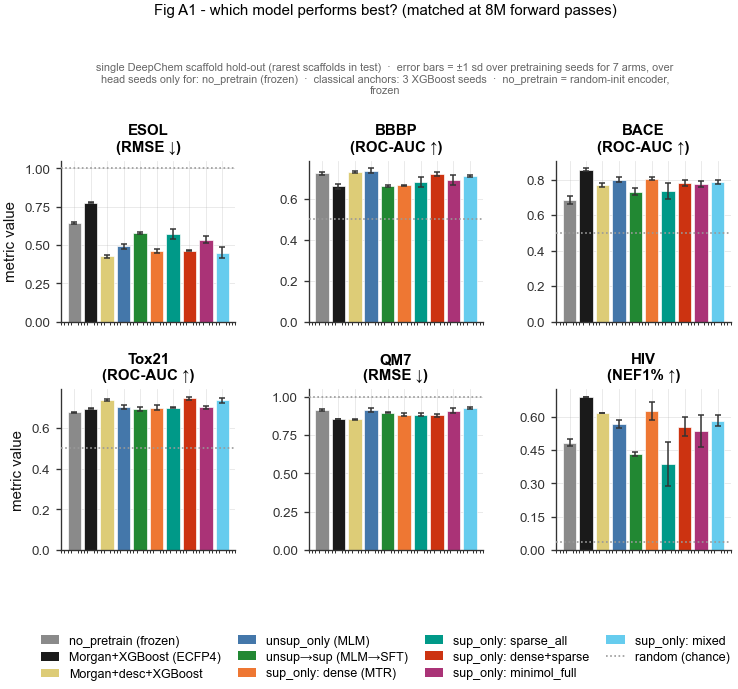


A1 mean lift over no_pretrain at 8M (tasks scored / 6):
   no_pretrain (frozen)         +0.0%   (n=6)
   Morgan+XGBoost (ECFP4)       +7.8%   (n=6)
   Morgan+desc+XGBoost         +15.1%   (n=6)
   unsup_only (MLM)            +10.7%   (n=6)
   unsup→sup (MLM→SFT)          +0.3%   (n=6)
   sup_only: dense (MTR)       +12.4%   (n=6)
   sup_only: sparse_all         +0.0%   (n=6)
   sup_only: dense+sparse      +11.8%   (n=6)
   sup_only: minimol_full       +6.7%   (n=6)
   sup_only: mixed             +11.8%   (n=6)


In [5]:
# ---------- A1 · headline bars at the matched budget ----------
A1_ORDER=["no_pretrain","ecfp4","fp_desc","unsup_only","unsup2sup"]+[f"sup_only:{r}" for r in sup_recipes]

ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.35*nrow)); axes=axes.ravel()
for ax,task in zip(axes,CORE_TASKS):
    vals=[arm_value(DF,task,k) for k in A1_ORDER]
    errs=[arm_err(DF,task,k)   for k in A1_ORDER]
    x=np.arange(len(A1_ORDER))
    fin=[v for v in vals if np.isfinite(v)]; ymax=max(fin) if fin else 1.0
    for xi,k,v,e in zip(x,A1_ORDER,vals,errs):
        if not np.isfinite(v): continue
        ax.bar(xi,v,color=rc_color(k),edgecolor="white",lw=0.4,width=0.82,
               yerr=(e if np.isfinite(e) else None),
               error_kw=dict(ecolor="#333333",elinewidth=0.9,capsize=2,capthick=0.9))
    # A missing bar simply vanishes, which a reader cannot tell from a zero-height bar. Name them.
    pending=[rc_label(k) for k,v in zip(A1_ORDER,vals) if not np.isfinite(v)]
    if pending:
        # headroom first, so the note never lands on top of a bar
        ax.set_ylim(top=ax.get_ylim()[1]*(1.10+0.09*int(np.ceil(len(pending)/2))))
        ax.text(0.02,0.985,"pending:\n"+"\n".join(pending),transform=ax.transAxes,ha="left",va="top",
                fontsize=STYLE["fs_annot"]-1.5,color="#B00020",linespacing=1.25,
                bbox=dict(fc="white",ec="none",alpha=0.85,pad=1.0))
    add_chance_line(ax,task)
    ax.set_title(ttitle(task),pad=6); ax.set_xticks(x); ax.set_xticklabels([])
    ax.tick_params(axis="x",length=0); ax.margins(x=0.04); label_all_yticks(ax)
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")

handles=[mpl.patches.Patch(facecolor=rc_color(k),label=rc_label(k)) for k in A1_ORDER]
handles+=[plt.Line2D([],[],color="#999999",ls=(0,(1,1.5)),lw=1.0,label="random (chance)")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=4,
           fontsize=STYLE["fs_legend"],handlelength=1.5,columnspacing=1.3)

# replication note, computed from the data so it cannot go stale
_multi=[rc_label(k) for k in A1_ORDER if n_seeds(DF,"ESOL",k)>1 and not k.startswith(("ecfp4","fp_desc"))]
_single=[rc_label(k) for k in A1_ORDER if n_seeds(DF,"ESOL",k)==1 and not k.startswith(("ecfp4","fp_desc"))]
_note=(f"single DeepChem scaffold hold-out (rarest scaffolds in test)  ·  "
       f"error bars = ±1 sd over pretraining seeds for {len(_multi)} arms"
       + (f", over head seeds only for: {', '.join(_single)}" if _single else "")
       + "  ·  classical anchors: 3 XGBoost seeds  ·  no_pretrain = random-init encoder, frozen")
import textwrap as _tw
fig.suptitle(f"Fig A1 - which model performs best? (matched at {MATCHED_BUDGET} forward passes)",
             fontsize=STYLE["fs_title"],y=1.10)
fig.text(0.5,0.995,"\n".join(_tw.wrap(_note,125)),ha="center",va="top",
         fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.82,bottom=0.13,hspace=0.42,wspace=0.42)
save_fig(fig,"figA1_best_model_headline"); plt.show()

# ranking summary: mean lift over no_pretrain across the tasks each arm actually has
print(f"\nA1 mean lift over no_pretrain at {MATCHED_BUDGET} (tasks scored / {len(CORE_TASKS)}):")
for k in A1_ORDER:
    ls=[lift(arm_value(DF,t,k),t,npt_floor(DF,t)) for t in CORE_TASKS]
    ls=[v for v in ls if np.isfinite(v)]
    if ls: print(f"   {rc_label(k):<26} {100*np.mean(ls):+6.1f}%   (n={len(ls)})")

## A2 · How does pretraining scale in forward passes?

Ladders for the primary regimes against the `no_pretrain` floor. `unsup→sup` is drawn at its
**true** total compute (MLM base + 2 M-FP SFT stage), so the arm is not flattered by hiding its
extra spend.

The shaded band on the right marks the **larger unsupervised runs still to come** (96 M FP, and a
corpus scaled toward ~100 M unique molecules). It contains no data — it is there so the reader can
see where the ladder is about to be extended rather than assuming it ends at 48 M.

saved figA2_scaling_forward_passes


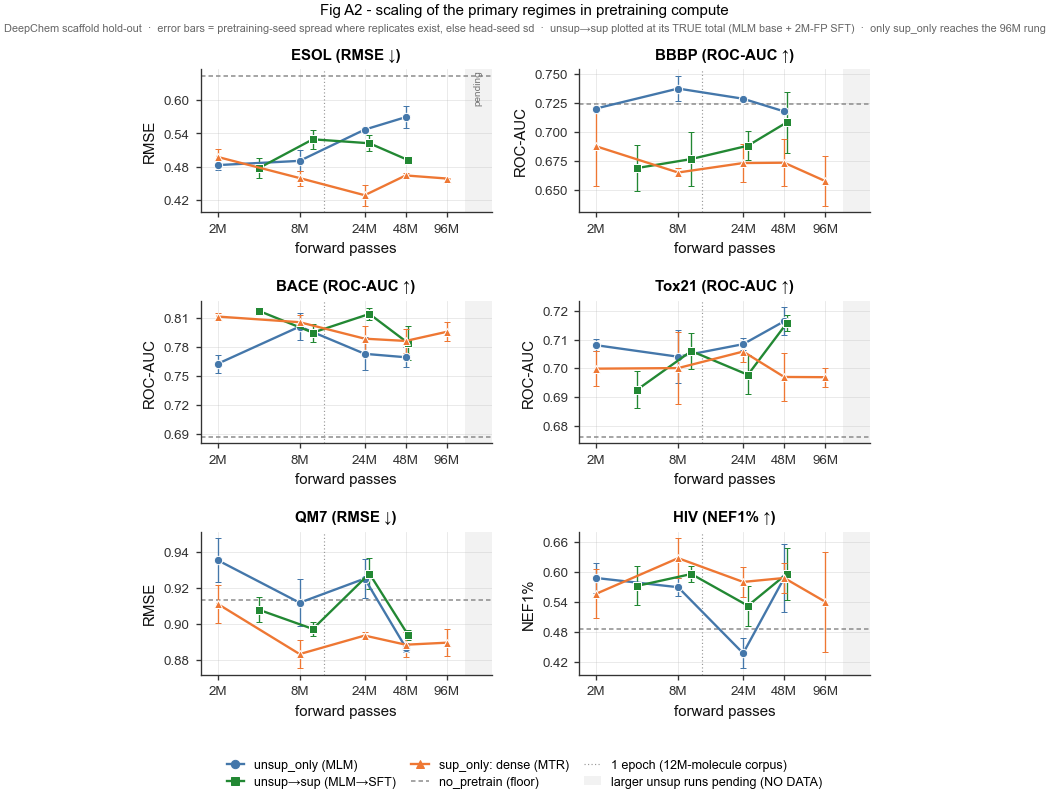

A2 unsup_only (MLM)           mean change from smallest to largest budget: -1.8%
A2 unsup→sup (MLM→SFT)        mean change from smallest to largest budget: +1.3%
A2 sup_only: dense (MTR)      mean change from smallest to largest budget: +0.1%


In [6]:
# ---------- A2 · scaling ladders, primary regimes ----------
A2_KEYS=["unsup_only","unsup2sup",f"sup_only:{BEST_SUP}"]
# unsup2sup is restricted to the SAME recipe as the sup_only line: otherwise all five u2s recipes
# collapse into one series and the vertical smear reads as an error bar when it is really five
# different models.
def ladder(task,key):
    if key=="unsup_only":   s=DF[(DF.regime=="unsup_only")&(DF.task==task)]
    elif key=="unsup2sup":  s=DF[(DF.regime=="unsup2sup")&(DF.recipe==BEST_SUP)&(DF.task==task)]
    else:                   s=DF[(DF.regime=="sup_only")&(DF.recipe==key.split(":")[1])&(DF.task==task)]
    s=s[(s.wave=="climb_v2_phase2")&(~s.truncated)].copy()
    if not len(s): return s
    # average across pretraining seeds at each budget, and use their spread as the error bar
    g=s.groupby("budget_fp").agg(value=("value","mean"),sd=("value","std"),
                                 hs=("std","mean"),n=("seed","nunique")).reset_index()
    g["err"]=np.where(g.n>1,g.sd,g.hs)
    return g.sort_values("budget_fp")

# 96M is a REAL rung: skip_dense_96M reached 95,994,624 / 96,000,000 FP (verified.json). It was
# on the old hand-maintained truncation blocklist at 3.07M -- stale, and exactly why completion is
# now derived from achieved forward passes instead of a curated list.
BUDG=[2e6,8e6,24e6,48e6,96e6]
PENDING_LO,PENDING_HI=1.30e8,2.05e8    # region reserved for the runs still in flight
# TWO columns, not three: at three the 24M and 48M tick labels overlapped -- they are only a
# factor 2 apart on a log axis that now also has to make room for the pending band.
ncol=2; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.05*nrow)); axes=axes.ravel()
for i,(ax,task) in enumerate(zip(axes,CORE_TASKS)):
    drew=False
    for key in A2_KEYS:
        g=ladder(task,key)
        if not len(g): continue
        drew=True
        ax.errorbar(g.budget_fp,g.value,yerr=g.err,color=rc_color(key),ls=rc_ls(key),lw=STYLE["lw"],
                    marker=rc_marker(key),ms=STYLE["marker_size"],mec="white",capsize=2,
                    elinewidth=0.8,zorder=3)
    fl=npt_floor(DF,task)
    if np.isfinite(fl): ax.axhline(fl,color=rc_color("no_pretrain"),ls=(0,(3,2)),lw=0.9,zorder=1)
    ax.axvspan(PENDING_LO,PENDING_HI,color=PALETTE["grey2"],alpha=0.22,lw=0,zorder=0)
    set_fp_axis(ax,BUDG); ax.set_xlim(1.5e6,PENDING_HI)
    ax.set_title(ttitle(task,oneline=True),pad=6); ax.set_xlabel("forward passes")
    ax.set_ylabel(re.sub(r"\s*[↑↓]\s*$","",mlabel(task)))   # arrow lives in the title
    ax.axvline(12e6,color="#999",ls=(0,(1,2)),lw=0.7,zorder=1)        # corpus size = 12M molecules
    label_all_yticks(ax)
    if i==0:
        ax.text(np.sqrt(PENDING_LO*PENDING_HI),ax.get_ylim()[1],"pending",rotation=90,
                ha="center",va="top",fontsize=STYLE["fs_annot"]-1,color="#777")
    if not drew: no_data_watermark(ax,"no completed runs")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")

handles=[plt.Line2D([],[],color=rc_color(k),marker=rc_marker(k),ls=rc_ls(k),label=rc_label(k)) for k in A2_KEYS]
handles+=[plt.Line2D([],[],color=rc_color("no_pretrain"),ls=(0,(3,2)),lw=0.9,label="no_pretrain (floor)"),
          plt.Line2D([],[],color="#999",ls=(0,(1,2)),lw=0.7,label="1 epoch (12M-molecule corpus)"),
          mpl.patches.Patch(facecolor=PALETTE["grey2"],alpha=0.22,
                            label="larger unsup runs pending (NO DATA)")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=3,
           fontsize=STYLE["fs_legend"],columnspacing=1.2)
fig.suptitle("Fig A2 - scaling of the primary regimes in pretraining compute",
             fontsize=STYLE["fs_title"],y=1.01)
fig.text(0.5,0.982,"DeepChem scaffold hold-out  ·  error bars = pretraining-seed spread where "
         "replicates exist, else head-seed sd  ·  unsup→sup plotted at its TRUE total "
         "(MLM base + 2M-FP SFT)  ·  only sup_only reaches the 96M rung",
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.92,bottom=0.10,hspace=0.62,wspace=0.30)
save_fig(fig,"figA2_scaling_forward_passes"); plt.show()

for key in A2_KEYS:
    spans=[]
    for t in CORE_TASKS:
        g=ladder(t,key)
        if len(g)>=2:
            d=lift(g.value.iloc[-1],t,g.value.iloc[0])
            spans.append(100*d)
    if spans:
        print(f"A2 {rc_label(key):<26} mean change from smallest to largest budget: {np.mean(spans):+.1f}%")

## B1p1 · Does pretraining help small datasets more — and through which mechanism?

Frozen probes on the 8 M encoders, trained on 100 → 3 000 → all labels (3 subsample draws × 3 head
seeds per point).

- **Solid = test, dashed = train, same colour per regime.** Test alone cannot tell "the head cannot
  *fit* this many labels" from "it fits and fails to *generalize*"; the train–test gap can.
- A large gap at small *N* → data-limited (fits, does not generalize). Both curves low → the frozen
  representation is capacity-limited.

Train and test must be the *same* metric to be comparable, so HIV is scored by ROC-AUC here rather
than by the NEF1% used elsewhere (there is no NEF1%-on-train).

saved figB1p1_label_efficiency_train_test


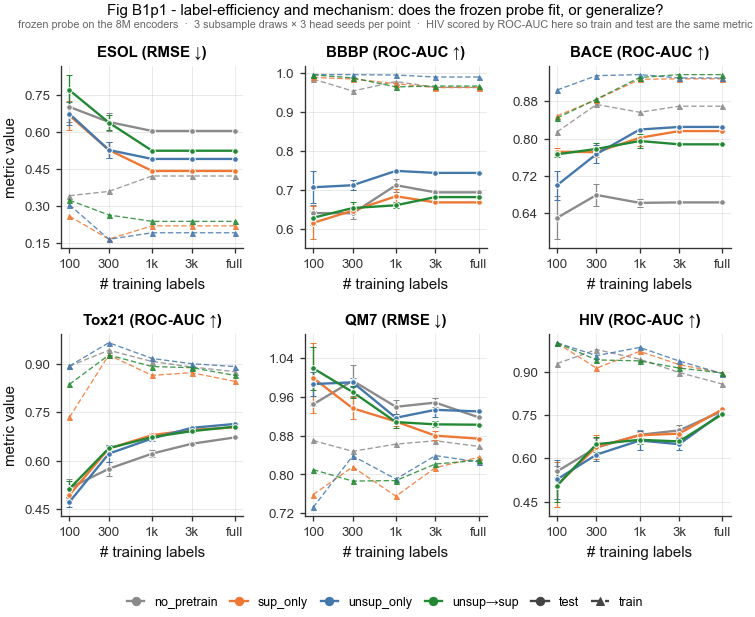


B1p1 mean |train - test| gap, smallest vs largest label budget:
   no_pretrain    n=100: 0.286   full: 0.169
   sup_only       n=100: 0.305   full: 0.156
   unsup_only     n=100: 0.335   full: 0.178
   unsup→sup      n=100: 0.319   full: 0.183


In [7]:
# ---------- B1p1 · label-efficiency, train vs test ----------
LE="figure_data/climb_v2_labeleff_v2"
LE_REGIMES=[("random","no_pretrain",rc_color("no_pretrain")),
            ("sup","sup_only",PALETTE["orange"]),
            ("unsup","unsup_only",rc_color("unsup_only")),
            ("unsup2sup","unsup→sup",rc_color("unsup2sup"))]
LE_SIZES=[("100",100),("300",300),("1000",1000),("3000",3000),("0",10000)]

_LE={}
for f in glob.glob(f"{LE}/*/moleculenet/moleculenet_summary.csv"):
    t=f.split("/")[-3].split("_"); size=t[-2].replace("n",""); reg="_".join(t[:-2])
    for _,r in pd.read_csv(f).query("head_seed=='MEAN'").iterrows():
        mm=str(r.main_metric)
        if   mm in ("rmse","roc_auc"): kind="test"
        elif mm.endswith("_train"):    kind="train"
        else: continue                            # nef1 etc: no train counterpart, skip
        _LE.setdefault((reg,size,r.dataset,kind),[]).append(r.main_value)
def le(reg,size,task,kind="test"):
    v=_LE.get((reg,size,task,kind),[])
    return (float(np.mean(v)), float(np.std(v)) if len(v)>1 else 0.0) if v else (np.nan,0.0)

ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.4*nrow)); axes=axes.ravel()
xs=[x for _,x in LE_SIZES]
for ax,task in zip(axes,CORE_TASKS):
    drew=False
    for reg,_,c in LE_REGIMES:
        te=[le(reg,s,task,"test")[0]  for s,_ in LE_SIZES]
        tr=[le(reg,s,task,"train")[0] for s,_ in LE_SIZES]
        ee=[le(reg,s,task,"test")[1]  for s,_ in LE_SIZES]
        if all(not np.isfinite(v) for v in te): continue
        drew=True
        ax.errorbar(xs,te,yerr=ee,color=c,marker="o",ms=3.4,lw=STYLE["lw"],mec="white",
                    capsize=2,elinewidth=0.8,zorder=3)
        ax.plot(xs,tr,color=c,marker="^",ms=3.0,lw=STYLE["lw_thin"],ls=(0,(4,2)),alpha=0.85,zorder=2)
    # HIV is scored by ROC-AUC in this figure (train has no NEF1% counterpart) -- the title has
    # to say so, or it silently contradicts the axis.
    _t=("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True))
    ax.set_xscale("log"); ax.set_title(_t,pad=6)
    ax.set_xlabel("# training labels")
    ax.xaxis.set_major_locator(ticker.FixedLocator(xs))
    ax.xaxis.set_major_formatter(ticker.FixedFormatter(["100","300","1k","3k","full"]))
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
    label_all_yticks(ax)
    if not drew: no_data_watermark(ax,"label-efficiency sweep missing")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")

reg_h=[plt.Line2D([],[],color=c,marker="o",label=lab) for _,lab,c in LE_REGIMES]
sty_h=[plt.Line2D([],[],color="#444",marker="o",ls="-",label="test"),
       plt.Line2D([],[],color="#444",marker="^",ls=(0,(4,2)),label="train")]
fig.legend(handles=reg_h+sty_h,loc="upper center",bbox_to_anchor=(0.5,0.0),ncol=6,
           fontsize=STYLE["fs_legend"])
fig.suptitle("Fig B1p1 - label-efficiency and mechanism: does the frozen probe fit, or generalize?",
             fontsize=STYLE["fs_title"],y=1.01)
fig.text(0.5,0.982,"frozen probe on the 8M encoders  ·  3 subsample draws × 3 head seeds per "
         "point  ·  HIV scored by ROC-AUC here so train and test are the same metric",
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.90,bottom=0.12,hspace=0.48,wspace=0.34)
save_fig(fig,"figB1p1_label_efficiency_train_test"); plt.show()

print("\nB1p1 mean |train - test| gap, smallest vs largest label budget:")
for reg,lab,_ in LE_REGIMES:
    out=[]
    for size in ("100","0"):
        g=[abs(le(reg,size,t,"train")[0]-le(reg,size,t,"test")[0]) for t in CORE_TASKS]
        g=[v for v in g if np.isfinite(v)]
        out.append(np.mean(g) if g else np.nan)
    print(f"   {lab:<14} n=100: {out[0]:.3f}   full: {out[1]:.3f}")

## E1 · H5 — is the `sup_only` / `unsup_only` ordering a frozen-probe artifact?

Every other figure scores a **frozen** encoder. Two things could be artifacts of that probe:

- the pretraining ladder looks **flat** — maybe the head is too weak to exploit a better encoder;
- `sup_only` and `unsup_only` sit in a particular **order** — maybe unfreezing reverses it.

The second is H5, and it needs *both* regimes in *both* conditions: a single frozen line and a
single fine-tuned line have nothing to flip against. So each task carries four series —
`unsup_only` and `sup_only` (`dense`, the best recipe by mean lift in A1), each frozen and
fine-tuned end-to-end, at matched 2M/8M/24M budgets.

- **(a)** the ladders. Open marker + dashed = frozen, filled + solid = fine-tuned.
- **(b)** the ordering test at the matched 8M budget: one segment per regime, frozen → fine-tuned.
  The two regimes are plotted side by side on a shared y-axis, so **a crossing between the
  segments is an ordering flip** and is impossible to miss.

Two cautions the panels carry in their caption. HIV is scored by ROC-AUC here, not the NEF1% used
elsewhere, because that is what the fine-tuning harness computes — train and test must be the same
metric on both sides of the comparison. And the two error bars are *not* the same quantity: a
frozen probe's only randomness is the head (the encoder is fixed, so its features are
deterministic), while a fine-tuning seed re-randomises the head **and** the whole encoder
optimisation.

saved figE1_H5_eval_ceiling


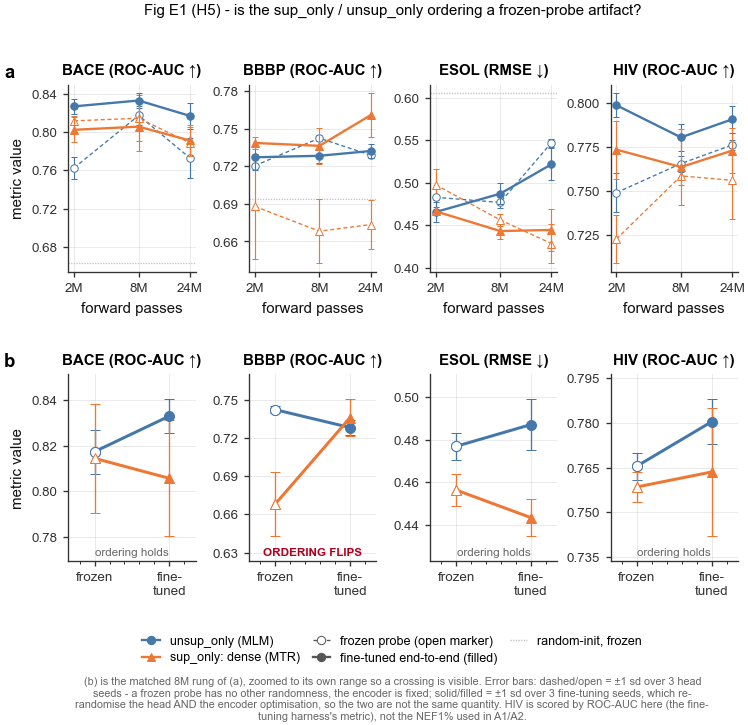


E1 (a) ladder shape - spread across the pretrained ladder vs the head-seed noise it must clear:
   unsup_only (MLM)       BACE  frozen=0.0546 (3.9x head-seed sd) finetuned=0.0160  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       BBBP  frozen=0.0220 (11.6x head-seed sd) finetuned=0.0050  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       ESOL  frozen=0.0700 (9.3x head-seed sd) finetuned=0.0560  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   unsup_only (MLM)       HIV   frozen=0.0271 (4.4x head-seed sd) finetuned=0.0183  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   sup_only: dense (MTR)  BACE  frozen=0.0257 (1.7x head-seed sd) finetuned=0.0144  -> fine-tuning COMPRESSES it: the probe was NOT the ceiling
   sup_only: dense (MTR)  BBBP  frozen=0.0198 (0.7x head-seed sd) finetuned=0.0244  -> fine-tuning SEPARATES them: the probe may be the ceiling
   sup_only: dense (MTR)  ESOL  frozen

In [8]:
# ---------- E1 · H5: regime-split eval ceiling ----------
# The first version of this figure plotted ONE frozen and ONE fine-tuned line, both from the
# unsup_only ladder. That answers a ladder-SHAPE question; it cannot answer H5, which is about the
# ORDERING of two regimes. sup_only is fine-tuned by scripts/run_e1_sup_gpu.sh into a separate
# output dir, merged here, so the 48 unsup fine-tunes are not redone.
CEIL     = DATA_ROOT/"_eval_ceiling"/"eval_ceiling.csv"
CEIL_SUP = DATA_ROOT/"_eval_ceiling_sup"/"eval_ceiling.csv"
E1_SUP_RECIPE = "dense"          # best sup_only recipe by mean lift in A1

def _regime_of(run_id):
    if run_id.startswith("random_baseline"): return "no_pretrain"
    if run_id.startswith("unsup_"):          return "unsup_only"
    m=re.match(r"skip_(.+)_\d+M$",run_id)
    return f"sup_only:{m[1]}" if m else None

_parts=[pd.read_csv(q) for q in (CEIL,CEIL_SUP) if q.exists()]
C = pd.concat(_parts,ignore_index=True) if _parts else pd.DataFrame()
if len(C):
    if "seed" not in C.columns: C["seed"]=0
    C["regime"]=C.run_id.map(_regime_of)

E1_REGIMES=[k for k in ("unsup_only",f"sup_only:{E1_SUP_RECIPE}")
            if len(C) and k in set(C.regime)]
_E1_PENDING=[k for k in ("unsup_only",f"sup_only:{E1_SUP_RECIPE}") if k not in E1_REGIMES]

if not len(C):
    fig,ax=plt.subplots(figsize=(STYLE["col15"],2.6))
    no_data_watermark(ax,"run scripts/run_e1_gpu.sh")
    fig.suptitle("Fig E1 (H5) [NO DATA]",fontsize=STYLE["fs_title"])
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()
else:
    nseed=C.seed.nunique()
    e1_tasks=[t for t in ("BACE","BBBP","ESOL","HIV") if t in set(C.task)]

    # Frozen values come from the run summaries PER HEAD SEED, not from the cached CSV: the CSV
    # collapsed them to a single MEAN and copied it onto every seed row, so its spread was zero.
    # Reading the summaries also keeps E1 on the same scorer as A1/A2.
    def _frozen_seeds(run_id,task):
        f=DATA_ROOT/"climb_v2_phase2"/run_id/"moleculenet"/"moleculenet_summary.csv"
        if not f.exists(): return np.array([])
        d=pd.read_csv(f)
        d=d[(d.dataset==task)&(d.main_metric.isin(["roc_auc","rmse"]))     # not _train, not nef1
            &(~d.head_seed.astype(str).isin(["MEAN","STD"]))]
        return d.main_value.values.astype(float)

    def e1_points(regime,task):
        """-> tidy frame: one row per budget with frozen/fine-tuned mean and sd."""
        s=C[(C.regime==regime)&(C.task==task)&(C.budget>0)]
        rows=[]
        for (rid,b),g in s.groupby(["run_id","budget"]):
            fz=_frozen_seeds(rid,task)
            rows.append(dict(run_id=rid,budget=b,
                             fz=(np.mean(fz) if len(fz) else np.nan),
                             fz_sd=(np.std(fz,ddof=1) if len(fz)>1 else np.nan),
                             ft=g.finetune.mean(),
                             ft_sd=(g.finetune.std() if len(g)>1 else np.nan)))
        return pd.DataFrame(rows).sort_values("budget") if rows else pd.DataFrame()

    def e1_random(task,col):
        s=C[(C.regime=="no_pretrain")&(C.task==task)]
        return s[col].mean() if len(s) else np.nan

    E1_STYLE={k:dict(c=rc_color(k),m=rc_marker(k) or "o") for k in E1_REGIMES}
    ncol=len(e1_tasks)
    fig,axes=plt.subplots(2,ncol,figsize=(STYLE["col2"],6.2),
                          gridspec_kw=dict(height_ratios=[1,1],hspace=0.55,wspace=0.42))
    axes=np.atleast_2d(axes)

    # ---------- (a) the ladders: 2 regimes x {frozen, fine-tuned} ----------
    for j,task in enumerate(e1_tasks):
        ax=axes[0,j]
        for k in E1_REGIMES:
            d=e1_points(k,task)
            if d.empty: continue
            st=E1_STYLE[k]
            ax.errorbar(d.budget,d.fz,yerr=d.fz_sd.fillna(0),color=st["c"],marker=st["m"],
                        ls=(0,(3,2)),lw=STYLE["lw_thin"],mfc="white",ms=4.5,
                        capsize=2,elinewidth=0.7,zorder=3)
            ax.errorbar(d.budget,d.ft,yerr=d.ft_sd.fillna(0),color=st["c"],marker=st["m"],
                        ls="-",lw=STYLE["lw"],ms=4.5,capsize=2,elinewidth=0.7,zorder=4)
        _rf=e1_random(task,"frozen")
        if np.isfinite(_rf):
            ax.axhline(_rf,ls=(0,(1,1)),color=PALETTE["grey2"],lw=STYLE["lw_thin"],zorder=1)
        _bud=sorted(C[(C.task==task)&(C.budget>0)].budget.unique())
        if _bud: set_fp_axis(ax,_bud)
        ax.set_xlabel("forward passes")
        ax.set_title(("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True)),pad=6)
        label_all_yticks(ax)
    axes[0,0].set_ylabel("metric value")
    panel_tag(axes[0,0],"a",dx=-0.42)

    # ---------- (b) the H5 ordering test at the matched budget ----------
    _flips=[]
    for j,task in enumerate(e1_tasks):
        ax=axes[1,j]
        hb=TASKS[task]["higher_better"] if task!="HIV" else True   # ROC-AUC here, so higher=better
        vals={}
        for k in E1_REGIMES:
            d=e1_points(k,task)
            if d.empty: continue
            r=d.iloc[(d.budget-BUDGET_FP[MATCHED_BUDGET]).abs().argsort().iloc[0]]
            st=E1_STYLE[k]
            ax.errorbar([0,1],[r.fz,r.ft],
                        yerr=[0 if not np.isfinite(r.fz_sd) else r.fz_sd,
                              0 if not np.isfinite(r.ft_sd) else r.ft_sd],
                        color=st["c"],marker=st["m"],ms=6,lw=STYLE["lw"]+0.4,
                        capsize=3,elinewidth=0.8,zorder=3)
            ax.plot([0],[r.fz],marker=st["m"],ms=6,color=st["c"],mfc="white",zorder=4)  # open=frozen
            vals[k]=(r.fz,r.ft)
        ax.set_xlim(-0.35,1.35); ax.set_xticks([0,1])
        ax.set_xticklabels(["frozen","fine-\ntuned"])
        ax.set_title(("HIV (ROC-AUC ↑)" if task=="HIV" else ttitle(task,oneline=True)),pad=6)
        label_all_yticks(ax)
        # Deliberately NOT sharing y with the ladder above: on the ladder's range the two segments
        # sit almost on top of each other and a crossing is invisible, which is the one thing this
        # panel exists to show. It is zoomed to its own data; the caption says so.
        ax.margins(y=0.18)
        # Does the ordering survive? Compare the sign of (unsup - sup) in each condition.
        if len(vals)==2:
            u,s_=vals["unsup_only"],vals[f"sup_only:{E1_SUP_RECIPE}"]
            better=lambda a,b:(a>b) if hb else (a<b)
            fz_u_wins,ft_u_wins=better(u[0],s_[0]),better(u[1],s_[1])
            flip = fz_u_wins!=ft_u_wins
            _flips.append((task,fz_u_wins,ft_u_wins,flip))
            ax.text(0.5,0.02,("ORDERING FLIPS" if flip else "ordering holds"),
                    transform=ax.transAxes,ha="center",va="bottom",
                    fontsize=STYLE["fs_annot"],fontweight=("bold" if flip else "normal"),
                    color=("#B00020" if flip else "#666"))
    axes[1,0].set_ylabel("metric value")
    panel_tag(axes[1,0],"b",dx=-0.42)

    handles=[plt.Line2D([],[],color=E1_STYLE[k]["c"],marker=E1_STYLE[k]["m"],ls="-",
                        label=rc_label(k)) for k in E1_REGIMES]
    handles+=[plt.Line2D([],[],color="#555",marker="o",mfc="white",ls=(0,(3,2)),
                         lw=STYLE["lw_thin"],label="frozen probe (open marker)"),
              plt.Line2D([],[],color="#555",marker="o",ls="-",label="fine-tuned end-to-end (filled)"),
              plt.Line2D([],[],color=PALETTE["grey2"],ls=(0,(1,1)),lw=STYLE["lw_thin"],
                         label="random-init, frozen")]
    fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.155),ncol=3,
               fontsize=STYLE["fs_legend"])
    fig.suptitle("Fig E1 (H5) - is the sup_only / unsup_only ordering a frozen-probe artifact?",
                 fontsize=STYLE["fs_title"],y=0.99)
    # One figure-level pending note: per-panel boxes landed on the data in all four panels, and
    # the missing arm is missing everywhere, so saying it four times bought nothing.
    if _E1_PENDING:
        fig.text(0.5,0.955,"PENDING - "+", ".join(rc_label(k) for k in _E1_PENDING)
                 +" not fine-tuned yet, so (b) cannot test the ordering",
                 ha="center",va="top",fontsize=STYLE["fs_annot"],color="#B00020",fontweight="bold")
    _fzn=max([len(_frozen_seeds(r,e1_tasks[0])) for r in C.run_id.unique()]+[0])
    _note=(f"(b) is the matched {MATCHED_BUDGET} rung of (a), zoomed to its own range so a "
           f"crossing is visible. Error bars: dashed/open = ±1 sd over "
           f"{_fzn} head seeds - a frozen probe has no other randomness, the encoder is fixed; "
           f"solid/filled = ±1 sd over {nseed} fine-tuning seeds, which re-randomise the head AND "
           f"the encoder optimisation, so the two are not the same quantity. HIV is scored by "
           f"ROC-AUC here (the fine-tuning harness's metric), not the NEF1% used in A1/A2.")
    fig.subplots_adjust(top=0.88,bottom=0.24)
    fig.text(0.5,0.085,"\n".join(_tw.wrap(_note,132)),ha="center",va="top",
             fontsize=STYLE["fs_annot"]-0.5,color="#666")
    save_fig(fig,"figE1_H5_eval_ceiling"); plt.show()

    # ---------- printed readouts ----------
    if _E1_PENDING:
        print("E1: STILL PENDING -> "+", ".join(rc_label(k) for k in _E1_PENDING)
              +"  (run scripts/run_e1_sup_gpu.sh)")
    print(f"\nE1 (a) ladder shape - spread across the pretrained ladder vs the head-seed noise "
          f"it must clear:")
    for k in E1_REGIMES:
        for task in e1_tasks:
            d=e1_points(k,task)
            if len(d)<2: continue
            noise=np.nanmean(d.fz_sd.values)
            dz,dt=d.fz.max()-d.fz.min(),d.ft.max()-d.ft.min()
            verdict=("fine-tuning COMPRESSES it: the probe was NOT the ceiling" if dt<dz
                     else "fine-tuning SEPARATES them: the probe may be the ceiling")
            print(f"   {rc_label(k):<22} {task:<5} frozen={dz:.4f} ({dz/noise:.1f}x head-seed sd) "
                  f"finetuned={dt:.4f}  -> {verdict}")
    if _flips:
        print(f"\nE1 (b) H5 ordering at {MATCHED_BUDGET} (does unsup_only beat sup_only?):")
        for task,fz_u,ft_u,flip in _flips:
            print(f"   {task:<5} frozen: {'unsup' if fz_u else 'sup'} ahead   "
                  f"fine-tuned: {'unsup' if ft_u else 'sup'} ahead   "
                  f"-> {'FLIPS' if flip else 'holds'}")
        nf=sum(f for _,_,_,f in _flips)
        print(f"   {nf}/{len(_flips)} tasks flip. "
              +("The frozen ordering is NOT preserved under fine-tuning." if nf>len(_flips)/2
                else "The frozen ordering largely survives fine-tuning, so it is not a probe artifact."))

## B2 · If we pretrain on a *garbled* objective, do the benefits survive?

The E13 control holds objective, data volume, compute, schedule and model fixed and removes only
the **chemical content**:

- `corrupt_mlm` — token order permuted inside each sequence (SMILES grammar destroyed, token
  distribution and mask rate preserved).
- `corrupt_mtr` — descriptor targets permuted across the batch (molecule→descriptor mapping
  destroyed, target distribution untouched).

How to read it: *corrupted ≈ no_pretrain, real > both* ⇒ pretraining adds **information**.
*corrupted ≈ real* ⇒ the gain comes from the objective's structure (initialization / regularization),
not from chemistry.

saved figB2_corrupted_control


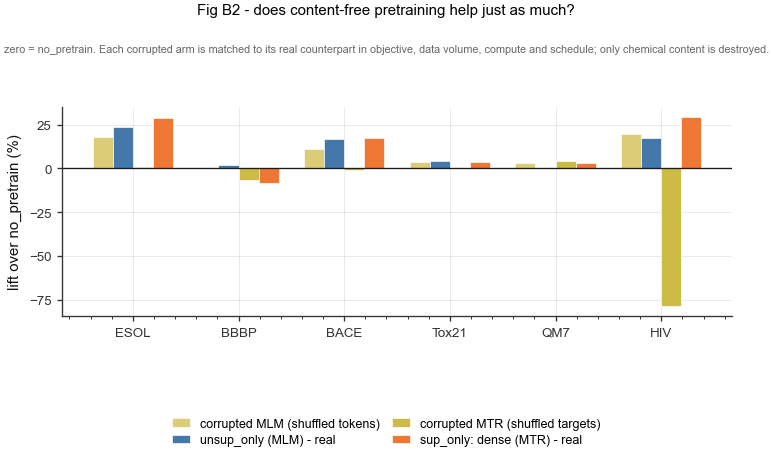

B2 mean lift over no_pretrain across the core tasks:
   corrupted MLM (shuffled tokens)            +9.3%  (n=6)
   unsup_only (MLM) - real                   +10.7%  (n=6)
   corrupted MTR (shuffled targets)          -13.5%  (n=6)
   sup_only: dense (MTR) - real              +12.4%  (n=6)


In [9]:
# ---------- B2 · corrupted-pretraining control ----------
B2_PAIRS=[("corrupt_mlm","corrupted MLM (shuffled tokens)","unsup_only", PALETTE["sand"]),
          ("corrupt_mtr","corrupted MTR (shuffled targets)","sup_only:dense",PALETTE["yellow"])]
_have_b2=any(len(arm_rows(DF,"ESOL",k)) for k,_,_,_ in B2_PAIRS)

fig,ax=plt.subplots(figsize=(STYLE["col2"],2.9))
x=np.arange(len(CORE_TASKS)); w=0.19
series=[("corrupt_mlm","corrupted MLM (shuffled tokens)",PALETTE["sand"]),
        ("unsup_only", rc_label("unsup_only")+" - real",  rc_color("unsup_only")),
        ("corrupt_mtr","corrupted MTR (shuffled targets)",PALETTE["yellow"]),
        ("sup_only:dense", rc_label("sup_only:dense")+" - real", rc_color("sup_only:dense"))]
for i,(key,lab,c) in enumerate(series):
    ys=[100*lift(arm_value(DF,t,key),t,npt_floor(DF,t)) for t in CORE_TASKS]
    ax.bar(x+(i-1.5)*w,ys,width=w,color=c,edgecolor="white",lw=0.4,label=lab)
ax.axhline(0,color=PALETTE["black"],lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([TASKS[t]["pretty"] for t in CORE_TASKS])
ax.set_ylabel("lift over no_pretrain (%)"); label_all_yticks(ax)
if not _have_b2:
    # The REAL arms already have data, so forcing a placeholder ylim clipped their bars and a
    # centred watermark covered them. Keep the real data honest; flag the missing arms in a corner.
    ax.text(0.5,1.02,"CORRUPTED ARMS NOT YET AVAILABLE — corrupt_mlm_8M / corrupt_mtr_8M still training",
            transform=ax.transAxes,ha="center",va="bottom",fontsize=STYLE["fs_annot"],
            color="#B00020",fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",fc="#FCE8E8",ec="#B00020",lw=0.8))
fig.legend(loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
_tag=" [PLACEHOLDER - control runs pending]" if not _have_b2 else ""
fig.suptitle("Fig B2 - does content-free pretraining help just as much?"+_tag,
             fontsize=STYLE["fs_title"],y=1.18)
fig.text(0.5,1.06,"zero = no_pretrain. Each corrupted arm is matched to its real counterpart in "
         "objective, data volume, compute and schedule; only chemical content is destroyed.",
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(bottom=0.28)
save_fig(fig,"figB2_corrupted_control"+("" if _have_b2 else "_PLACEHOLDER")); plt.show()

if _have_b2:
    print("B2 mean lift over no_pretrain across the core tasks:")
    for key,lab,_ in [(k,l,c) for k,l,c in series]:
        ls=[lift(arm_value(DF,t,key),t,npt_floor(DF,t)) for t in CORE_TASKS]
        ls=[v for v in ls if np.isfinite(v)]
        if ls: print(f"   {lab:<40} {100*np.mean(ls):+6.1f}%  (n={len(ls)})")
else:
    print("B2: no corrupted-control data yet. Expected runs: corrupt_mlm_8M, corrupt_mtr_8M "
          "(8M FP each, matched to unsup_8M / skip_dense_8M).")

## C1J1 · Which supervised pretraining data helps, how much, and does it track chemistry?

One figure, three panels, because the three questions share the same runs and plotting them apart
duplicated the same numbers twice:

- **(a)** Average lift over `no_pretrain` per arm — *which SFT label type is most beneficial?*
- **(b)** The same lift resolved per evaluation task — *where does each family transfer to?*
- **(c)** The **H10 test**: does that transfer track chemical similarity between the SFT family and
  the evaluation task? Each point is one arm × task cell from (b). x is mean max ECFP4 **Tanimoto
  similarity** — further right means the eval molecules are *more* similar to what the arm trained
  on. A positive slope would support content-similarity-driven transfer.

All arms are `unsup→sup` from one shared MLM base, evaluated identically. This is the **deduped**
wave: the SFT blocklist drops 34 301 eval molecules, so no arm trains on eval-test molecules and
(c) measures genuine near-neighbour chemistry rather than memorization.

   floor differs between waves on ESOL: dedup=0.6102 vs phase2=0.6437 (5.2%) - each arm uses its own wave's floor
   floor differs between waves on BBBP: dedup=0.6951 vs phase2=0.7241 (4.0%) - each arm uses its own wave's floor
   floor differs between waves on BACE: dedup=0.6787 vs phase2=0.6869 (1.2%) - each arm uses its own wave's floor
   floor differs between waves on Tox21: dedup=0.6707 vs phase2=0.6762 (0.8%) - each arm uses its own wave's floor
   floor differs between waves on HIV: dedup=0.4180 vs phase2=0.4841 (13.7%) - each arm uses its own wave's floor


saved figC1J1_sft_family_transfer


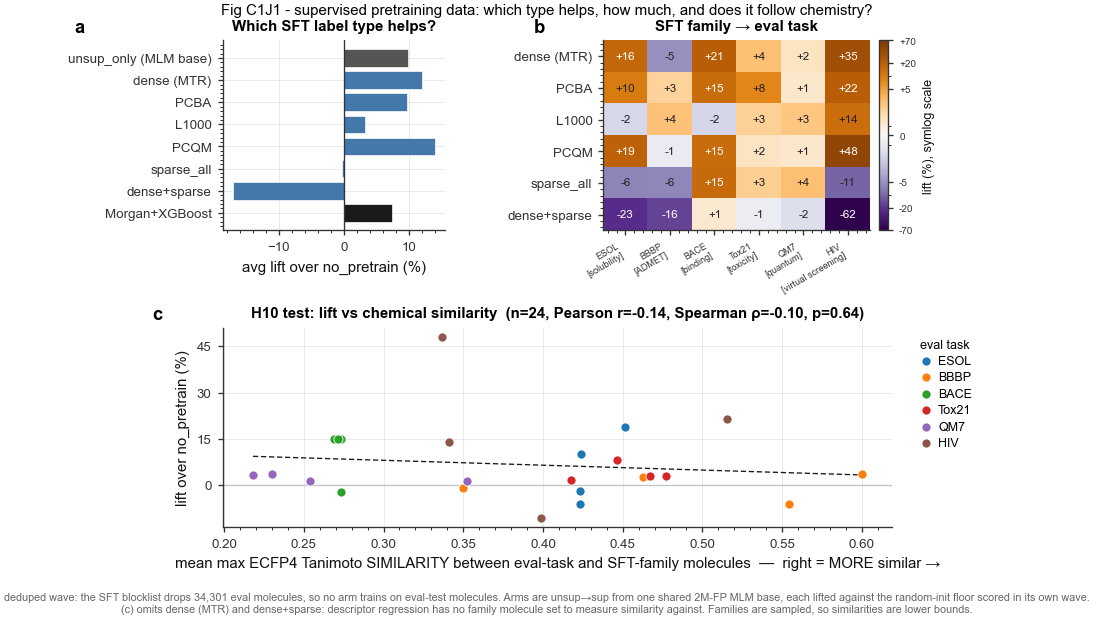

C1J1 (a) mean lift over no_pretrain:
   unsup_only (MLM base)      +9.8%
   dense (MTR)               +12.1%
   PCBA                       +9.7%
   L1000                      +3.2%
   PCQM                      +14.0%
   sparse_all                 -0.3%
   dense+sparse              -17.1%
   Morgan+XGBoost             +7.4%

C1J1 (c) H10: n=24 arm x task cells, Pearson r=-0.138, Spearman rho=-0.099 (p=0.645), similarity range 0.22-0.60
   within ESOL  : rho=+0.80 (n=4)
   within BBBP  : rho=+0.40 (n=4)
   within BACE  : rho=-0.40 (n=4)
   within Tox21 : rho=+0.20 (n=4)
   within QM7   : rho=-0.60 (n=4)
   within HIV   : rho=-0.40 (n=4)


In [10]:
# ---------- C1J1 · SFT-family ablation + transfer matrix + the H10 similarity test ----------
ABL="climb_v2_ablation_dedup"
ABL_ARMS=["seq_mtr","seq_pcba","seq_l1000","seq_pcqm","seq_sparse_all","seq_dense_plus_sparse"]
ABL_LABEL={"seq_mtr":"dense (MTR)","seq_pcba":"PCBA","seq_l1000":"L1000","seq_pcqm":"PCQM",
           "seq_sparse_all":"sparse_all","seq_dense_plus_sparse":"dense+sparse"}
# The ablation arms warm-start from climb_v2_phase2/unsup_2M, so THAT is the MLM base to show as
# the reference row -- not the round-1 unsup_only run the earlier version of this figure used.
BASE_RUN=(DATA_ROOT/"climb_v2_phase2"/"unsup_2M")

def _wave_floor(wave,task):
    """Mean of the three random-init encoders AS SCORED IN THAT WAVE."""
    v=[]
    for rb in sorted((DATA_ROOT/wave).glob("random_baseline*/")):
        d=load_suite(rb); sk=TASKS[task].get("suite_key",task)
        if d and (sk,"mean") in d: v.append(d[(sk,"mean")])
    return float(np.mean(v)) if v else np.nan
abl_floor=lambda task:_wave_floor(ABL,task)

# The two waves run the SAME three random-init encoders, but they were scored in separate eval
# runs, and re-scoring shifts a metric by up to ~0.03. So each arm is lifted against the floor
# from ITS OWN wave -- comparing lifts, each internally consistent -- rather than against one
# borrowed floor. The divergence is printed so the size of the effect is visible, not assumed away.
for _t in CORE_TASKS:
    _a,_b=abl_floor(_t),npt_floor(DF,_t)
    if np.isfinite(_a) and np.isfinite(_b) and abs(_a-_b)>5e-3:
        print(f"   floor differs between waves on {_t}: dedup={_a:.4f} vs phase2={_b:.4f} "
              f"({100*abs(_a-_b)/_b:.1f}%) - each arm uses its own wave's floor")

rows=[]
_srcs=[("unsup_only (MLM base)",BASE_RUN,"climb_v2_phase2")]+\
      [(ABL_LABEL[a],DATA_ROOT/ABL/a,ABL) for a in ABL_ARMS]+\
      [("Morgan+XGBoost",DATA_ROOT/ABL/"ecfp4_anchor",ABL)]
for disp,rd,wv in _srcs:
    d=load_suite(rd)
    if not d: continue
    for task in CORE_TASKS:
        sk=TASKS[task].get("suite_key",task)
        if (sk,"mean") in d:
            rows.append(dict(arm=disp,task=task,lift=lift(d[(sk,"mean")],task,_wave_floor(wv,task))))
AB=pd.DataFrame(rows)
ARM_ORDER=[a for a in ["unsup_only (MLM base)"]+[ABL_LABEL[a] for a in ABL_ARMS]+["Morgan+XGBoost"]
           if a in set(AB.arm)]

fig=plt.figure(figsize=(STYLE["col2"],5.2))
gs=fig.add_gridspec(2,2,width_ratios=[1,1.30],height_ratios=[1,1.05],hspace=0.50,wspace=0.62)
axA=fig.add_subplot(gs[0,0]); axB=fig.add_subplot(gs[0,1]); axC=fig.add_subplot(gs[1,:])

# --- (a) mean lift per arm ---
avg=AB.groupby("arm").lift.mean().reindex(ARM_ORDER)*100
cols=["#555555" if a.startswith("unsup_only") else
      (PALETTE["black"] if a=="Morgan+XGBoost" else PALETTE["blue"]) for a in ARM_ORDER]
axA.barh(range(len(ARM_ORDER)),avg.values,color=cols,edgecolor="white",lw=0.4)
axA.axvline(0,color="#333",lw=0.8)
axA.set_yticks(range(len(ARM_ORDER))); axA.set_yticklabels(ARM_ORDER); axA.invert_yaxis()
axA.set_xlabel("avg lift over no_pretrain (%)")
axA.set_title("Which SFT label type helps?",pad=6); panel_tag(axA,"a",dx=-0.62)

# --- (b) per-task transfer matrix (SFT families only; the base/anchor rows live in (a)) ---
MAT_ROWS=[ABL_LABEL[a] for a in ABL_ARMS if ABL_LABEL[a] in set(AB.arm)]
H=AB.pivot(index="arm",columns="task",values="lift").reindex(index=MAT_ROWS,columns=CORE_TASKS)*100
# HIV lift runs to -79%, so a linear +/-15 scale painted the whole HIV column one flat colour
# and hid a 60-point spread. A symmetric-log norm keeps the small +/-5% structure readable while
# still ranking the large negatives honestly.
_vmax=float(np.nanmax(np.abs(H.values))); _vmax=max(20.0,np.ceil(_vmax/10)*10)
_norm=mpl.colors.SymLogNorm(linthresh=5,linscale=1.0,vmin=-_vmax,vmax=_vmax,base=10)
im=axB.imshow(H.values,cmap="PuOr_r",norm=_norm,aspect="auto")
axB.set_xticks(range(len(CORE_TASKS)))
axB.set_xticklabels([f'{TASKS[t]["pretty"]}\n[{TASKS[t]["domain"]}]' for t in CORE_TASKS],
                    fontsize=STYLE["fs_annot"]-1.5,rotation=30,ha="right")
axB.set_yticks(range(len(MAT_ROWS))); axB.set_yticklabels(MAT_ROWS)
axB.grid(False)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v=H.values[i,j]
        if np.isfinite(v):
            axB.text(j,i,f"{v:+.0f}",ha="center",va="center",fontsize=STYLE["fs_annot"],
                     color="white" if abs(v)>14 else "#222")
_cbt=[t for t in (-_vmax,-20,-5,0,5,20,_vmax) if abs(t)<=_vmax]
cb=fig.colorbar(im,ax=axB,fraction=0.046,pad=0.03,ticks=_cbt)
# SymLogNorm's default colorbar formatter drops every tick but 0; set the labels explicitly.
cb.ax.yaxis.set_major_formatter(ticker.FixedFormatter([f"{t:+.0f}".replace("+0","0") for t in _cbt]))
cb.set_label("lift (%), symlog scale",fontsize=STYLE["fs_legend"])
cb.ax.tick_params(labelsize=STYLE["fs_annot"]-1)
axB.set_title("SFT family → eval task",pad=6); panel_tag(axB,"b",dx=-0.22)

# --- (c) H10: does lift track chemical similarity? ---
SIMP=DATA_ROOT/"_tanimoto"/"family_task_similarity.csv"
# seq_mtr and seq_dense_plus_sparse are absent: descriptor regression has no family molecule set
# to measure similarity against, so they have no x-coordinate. They remain in (a) and (b).
ARM2FAM={"seq_pcba":["PCBA"],"seq_l1000":["L1000_MCF7","L1000_VCAP"],"seq_pcqm":["PCQM"],
         "seq_sparse_all":["PCBA","L1000_MCF7","L1000_VCAP"]}
pts=[]
if SIMP.exists():
    SIM=pd.read_csv(SIMP)
    for arm,fams in ARM2FAM.items():
        d=load_suite(DATA_ROOT/ABL/arm)
        if not d: continue
        for t in CORE_TASKS:
            sk=TASKS[t].get("suite_key",t)
            if (sk,"mean") not in d: continue
            l=lift(d[(sk,"mean")],t,abl_floor(t))
            m=SIM[(SIM.task==t)&(SIM.family.isin(fams))].mean_max_tanimoto.mean()
            if np.isfinite(l) and np.isfinite(m): pts.append((m,100*l,t,ABL_LABEL[arm]))
if len(pts)>=4:
    X=np.array([p[0] for p in pts]); Y=np.array([p[1] for p in pts]); TK=[p[2] for p in pts]
    cmap=plt.get_cmap("tab10"); tcol={t:cmap(i%10) for i,t in enumerate(CORE_TASKS)}
    for t in [t for t in CORE_TASKS if t in set(TK)]:
        m=[k==t for k in TK]
        axC.scatter(X[m],Y[m],s=30,color=tcol[t],edgecolor="white",lw=0.5,zorder=3,
                    label=TASKS[t]["pretty"])
    b,a=np.polyfit(X,Y,1); xs=np.linspace(X.min(),X.max(),50)
    axC.plot(xs,a+b*xs,color=PALETTE["black"],lw=STYLE["lw_thin"],ls=(0,(4,2)),zorder=2)
    axC.axhline(0,color=PALETTE["grey2"],lw=STYLE["lw_thin"],zorder=1)
    from scipy import stats as _st
    r=float(np.corrcoef(X,Y)[0,1]); rho,p=_st.spearmanr(X,Y)
    axC.set_xlabel("mean max ECFP4 Tanimoto SIMILARITY between eval-task and SFT-family molecules"
                   "  —  right = MORE similar →")
    axC.set_ylabel("lift over no_pretrain (%)")
    axC.set_title(f"H10 test: lift vs chemical similarity  (n={len(pts)}, "
                  f"Pearson r={r:+.2f}, Spearman ρ={rho:+.2f}, p={p:.2f})",pad=6)
    # legend OUTSIDE the axes: inside, the swatches read as extra data points
    axC.legend(title="eval task",loc="upper left",bbox_to_anchor=(1.02,1.0),frameon=False,
               fontsize=STYLE["fs_legend"],title_fontsize=STYLE["fs_legend"],handletextpad=0.3)
    label_all_yticks(axC)
else:
    no_data_watermark(axC,"run scripts/compute_family_task_similarity.py")
    axC.set_xlabel("family–task Tanimoto similarity  —  right = MORE similar →")
    axC.set_ylabel("lift over no_pretrain (%)")
panel_tag(axC,"c",dx=-0.09)

fig.suptitle("Fig C1J1 - supervised pretraining data: which type helps, how much, and does it "
             "follow chemistry?",fontsize=STYLE["fs_title"],y=0.98)
fig.text(0.5,0.035,"deduped wave: the SFT blocklist drops 34,301 eval molecules, so no arm trains on "
         "eval-test molecules. Arms are unsup→sup from one shared 2M-FP MLM base, each lifted "
         "against the random-init floor scored in its own wave.\n"
         "(c) omits dense (MTR) and dense+sparse: descriptor regression has no family molecule set to "
         "measure similarity against. Families are sampled, so similarities are lower bounds.",
         ha="center",va="top",fontsize=STYLE["fs_annot"]-0.5,color="#666")
fig.subplots_adjust(top=0.92,bottom=0.14)
save_fig(fig,"figC1J1_sft_family_transfer"); plt.show()

print("C1J1 (a) mean lift over no_pretrain:")
for a in ARM_ORDER: print(f"   {a:<24} {avg[a]:+6.1f}%")
if len(pts)>=4:
    print(f"\nC1J1 (c) H10: n={len(pts)} arm x task cells, Pearson r={r:+.3f}, "
          f"Spearman rho={rho:+.3f} (p={p:.3f}), similarity range {X.min():.2f}-{X.max():.2f}")
    for t in [t for t in CORE_TASKS if t in set(TK)]:
        m=[k==t for k in TK]
        if sum(m)>=3:
            print(f"   within {t:<6}: rho={_st.spearmanr(X[m],Y[m]).statistic:+.2f} (n={sum(m)})")

## I1 · Do corpus-similar or novel molecules benefit most from pretraining?

If the MLM gain came from **memorizing** the pretraining corpus, it should concentrate on eval
molecules close to that corpus and decay toward novel ones. If it came from a **representation**,
it should be roughly flat.

Per-molecule squared errors of `unsup_only` vs the random-init baselines, binned by each molecule's
max ECFP4 Tanimoto to the pretraining corpus. Regression tasks only — this needs a per-molecule
error, which ROC-AUC does not provide. Error bars are percentile bootstraps over molecules.

saved figI1_memorization_vs_representation


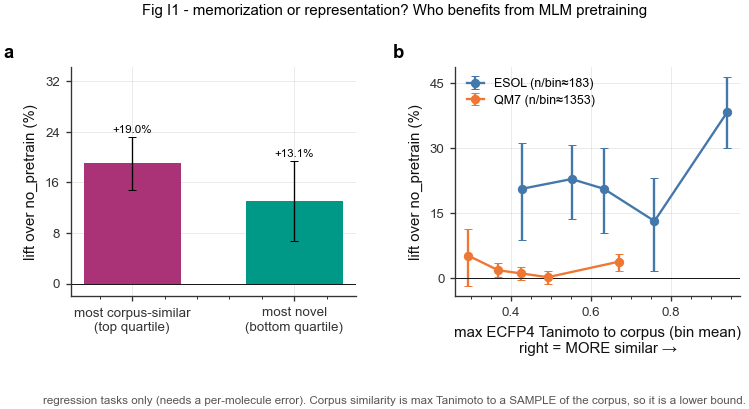

I1 ESOL: most-similar +34.4% [+25.6,+41.9]   most-novel +21.6% [+9.4,+31.6]  (95% bootstrap CI)
I1 QM7: most-similar +3.5% [+1.6,+5.4]   most-novel +4.7% [-1.3,+11.0]  (95% bootstrap CI)
Overlapping CIs => no evidence the gain concentrates on corpus-similar molecules, i.e. consistent with representation rather than memorization.


In [11]:
# ---------- I1 · memorization vs representation ----------
TANI=DATA_ROOT/"_tanimoto"/"corpus_similarity.csv"
I1_MODEL=f"unsup_{MATCHED_BUDGET}"
I1_BASE=["random_baseline_00","random_baseline_01","random_baseline_02"]
I1_TASKS=[t for t in ("ESOL","QM7") if t in TASKS]

def _preds(run):
    # per-molecule predictions exist only for the CV evaluation, so BOTH the model and its
    # baselines are read from CV here -- same scheme on both sides of the comparison.
    p=DATA_ROOT/"climb_v2_phase2"/run/"moleculenet_cv"/"test_predictions.csv"
    if not p.exists(): return None
    d=pd.read_csv(p)
    return (d.groupby(["dataset","raw_smiles"],as_index=False)
              .agg(y_true=("y_true","first"),y_pred=("y_pred","mean")))

def _lift_rmse(se_m,se_b):
    rm,rb=np.sqrt(np.mean(se_m)),np.sqrt(np.mean(se_b))
    return np.nan if (not np.isfinite(rb) or rb==0) else 100*(rb-rm)/rb

def binned_lift(task,nbins=5,nboot=400,seed=0):
    """-> (centres, lift%, lo, hi, n_per_bin) with a percentile bootstrap over molecules."""
    if not TANI.exists(): return (None,)*5
    mod=_preds(I1_MODEL)
    bases=[b for b in (_preds(r) for r in I1_BASE) if b is not None]
    if mod is None or not bases: return (None,)*5
    base=(pd.concat(bases).groupby(["dataset","raw_smiles"],as_index=False)
            .agg(y_true=("y_true","first"),y_pred=("y_pred","mean")))
    m=mod[mod.dataset==task].merge(base[base.dataset==task],on=["dataset","raw_smiles"],
                                   suffixes=("_m","_b"))
    m=m.merge(pd.read_csv(TANI)[["raw_smiles","max_tanimoto_to_corpus"]],on="raw_smiles",how="inner")
    if len(m)<50: return (None,)*5
    m["se_m"]=(m.y_pred_m-m.y_true_m)**2; m["se_b"]=(m.y_pred_b-m.y_true_b)**2
    edges=m.max_tanimoto_to_corpus.quantile(np.linspace(0,1,nbins+1)).values; edges[0]-=1e-9
    m["bin"]=pd.cut(m.max_tanimoto_to_corpus,bins=edges,labels=False,include_lowest=True)
    rng=np.random.default_rng(seed); xs,ys,los,his,ns=[],[],[],[],[]
    for b in range(nbins):
        s=m[m.bin==b]
        if len(s)<15: continue
        sm,sb=s.se_m.values,s.se_b.values
        pt=_lift_rmse(sm,sb)
        if not np.isfinite(pt): continue
        idx=rng.integers(0,len(sm),size=(nboot,len(sm)))
        boot=np.array([_lift_rmse(sm[i],sb[i]) for i in idx]); boot=boot[np.isfinite(boot)]
        lo,hi=(np.percentile(boot,[2.5,97.5]) if len(boot) else (np.nan,np.nan))
        xs.append(float(s.max_tanimoto_to_corpus.mean())); ys.append(pt)
        los.append(lo); his.append(hi); ns.append(int(len(s)))
    return xs,ys,los,his,ns

def quartile_lift(task):
    """(most-similar, most-novel) lift% with bootstrap CIs, from the outer quartiles."""
    xs,ys,lo,hi,_=binned_lift(task,nbins=4)
    if not xs or len(ys)<4: return None
    return (ys[-1],lo[-1],hi[-1]),(ys[0],lo[0],hi[0])

# Height + bottom margin reserve room for the caption INSIDE the canvas; at negative figure
# coords it only clears in the exported PNG (bbox="tight" grows it), not in the inline render.
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(STYLE["col2"],3.3))
pairs=[(t,v) for t,v in ((t,quartile_lift(t)) for t in I1_TASKS) if v]
if pairs:
    sim=float(np.mean([v[0][0] for _,v in pairs])); nov=float(np.mean([v[1][0] for _,v in pairs]))
    _se=lambda k: float(np.sqrt(np.sum([((v[k][2]-v[k][1])/2/len(pairs))**2 for _,v in pairs])))
    se_s,se_n=_se(0),_se(1)
    ax0.bar([0,1],[sim,nov],color=[PALETTE["purple"],PALETTE["teal"]],width=0.6,
            yerr=[se_s,se_n],capsize=STYLE["cap_size"],error_kw=dict(lw=STYLE["lw_thin"]))
    for xi,v,e in zip([0,1],[sim,nov],[se_s,se_n]):
        ax0.text(xi,v+e+0.6,f"{v:+.1f}%",ha="center",fontsize=STYLE["fs_annot"])
    ax0.axhline(0,color=PALETTE["black"],lw=0.6)
    lo_,hi_=min(0,sim-se_s,nov-se_n),max(0,sim+se_s,nov+se_n)
    ax0.set_ylim(lo_-abs(lo_)*0.35-2,hi_+abs(hi_)*0.35+3)
else:
    ax0.set_ylim(-5,15); no_data_watermark(ax0,"run scripts/compute_tanimoto_novelty.py")
ax0.set_xticks([0,1]); ax0.set_xticklabels(["most corpus-similar\n(top quartile)","most novel\n(bottom quartile)"])
ax0.set_ylabel("lift over no_pretrain (%)"); label_all_yticks(ax0); panel_tag(ax0,"a",dx=-0.20)

col={"ESOL":PALETTE["blue"],"QM7":PALETTE["orange"]}; drew=False
for t in I1_TASKS:
    xs,ys,lo,hi,nn=binned_lift(t)
    if not xs: continue
    drew=True
    err=np.vstack([np.array(ys)-np.array(lo),np.array(hi)-np.array(ys)])
    ax1.errorbar(xs,ys,yerr=err,color=col.get(t,PALETTE["grey"]),marker="o",lw=STYLE["lw"],
                 capsize=STYLE["cap_size"],label=f"{t} (n/bin≈{int(np.median(nn))})")
if drew:
    ax1.axhline(0,color=PALETTE["black"],lw=0.6)
    ax1.legend(loc="best",fontsize=STYLE["fs_legend"])
else:
    ax1.set_ylim(-5,15); no_data_watermark(ax1,"needs corpus_similarity.csv")
ax1.set_xlabel("max ECFP4 Tanimoto to corpus (bin mean)\nright = MORE similar →")
ax1.set_ylabel("lift over no_pretrain (%)"); label_all_yticks(ax1); panel_tag(ax1,"b",dx=-0.18)

fig.suptitle("Fig I1 - memorization or representation? Who benefits from MLM pretraining",
             fontsize=STYLE["fs_title"],y=1.04)
fig.subplots_adjust(top=0.88,bottom=0.30,wspace=0.35)
fig.text(0.5,0.05,"regression tasks only (needs a per-molecule error). Corpus similarity is max "
         "Tanimoto to a SAMPLE of the corpus, so it is a lower bound.",
         ha="center",va="top",fontsize=STYLE["fs_annot"],color="#555")
save_fig(fig,"figI1_memorization_vs_representation"); plt.show()

for t,v in pairs:
    print(f"I1 {t}: most-similar {v[0][0]:+.1f}% [{v[0][1]:+.1f},{v[0][2]:+.1f}]   "
          f"most-novel {v[1][0]:+.1f}% [{v[1][1]:+.1f},{v[1][2]:+.1f}]  (95% bootstrap CI)")
if pairs:
    print("Overlapping CIs => no evidence the gain concentrates on corpus-similar molecules, "
          "i.e. consistent with representation rather than memorization.")

## H1 · Does SMILES enumeration beat canonical repetition?

Beyond one epoch a model must re-see molecules. Enumeration re-shows each molecule under a
*different* valid SMILES string; canonical re-shows the identical string. If enumeration were
meaningful augmentation rather than noise, its curve should separate as the unique-molecule
fraction shrinks and repetition rises.

saved figH1_canonical_vs_enumerated


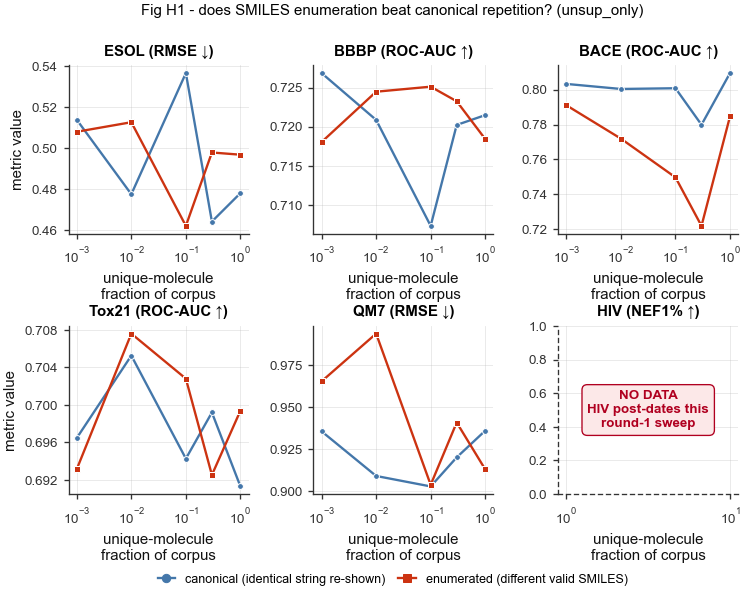

H1 enumerated minus canonical (positive = enumeration better), by unique-molecule fraction:
   frac=0.001  mean relative change -1.05%  (n=5)
   frac=0.01   mean relative change -3.88%  (n=5)
   frac=0.1    mean relative change +2.23%  (n=5)
   frac=0.3    mean relative change -3.50%  (n=5)
   frac=1.0    mean relative change -0.76%  (n=5)


In [12]:
# ---------- H1 · canonical vs enumerated SMILES ----------
FRACS=[("frac0p001",0.001),("frac0p01",0.01),("frac0p1",0.1),("frac0p3",0.3),("fracfull",1.0)]
# Six panels in a single row overlapped titles, tick labels and axis labels. 3x2 matches A1.
ncol=3; nrow=int(np.ceil(len(CORE_TASKS)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(STYLE["col2"],2.35*nrow)); axes=axes.ravel()
for ax,task in zip(axes,CORE_TASKS):
    drew=False
    for mode,c,mk in [("canonical",PALETTE["blue"],"o"),("enumerated",PALETTE["red"],"s")]:
        xs,ys=[],[]
        for fk,fv in FRACS:
            d=load_suite(DATA_ROOT/"climb_v2"/f"scaling_{mode}_{fk}")
            sk=TASKS[task].get("suite_key",task)
            if d and (sk,"mean") in d: xs.append(fv); ys.append(d[(sk,"mean")])
        if xs: drew=True; ax.plot(xs,ys,color=c,marker=mk,ms=3.5,lw=STYLE["lw"],mec="white")
    ax.set_xscale("log"); ax.set_title(ttitle(task,oneline=True),pad=6)
    ax.set_xlabel("unique-molecule\nfraction of corpus")
    ax.xaxis.set_minor_locator(ticker.NullLocator()); ax.tick_params(axis="x",which="minor",bottom=False)
    label_all_yticks(ax)
    if not drew: no_data_watermark(ax,"HIV post-dates this\nround-1 sweep")
for ax in axes[len(CORE_TASKS):]: ax.axis("off")
for i in range(0,len(CORE_TASKS),ncol): axes[i].set_ylabel("metric value")
handles=[plt.Line2D([],[],color=PALETTE["blue"],marker="o",label="canonical (identical string re-shown)"),
         plt.Line2D([],[],color=PALETTE["red"], marker="s",label="enumerated (different valid SMILES)")]
fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5,0.02),ncol=2,fontsize=STYLE["fs_legend"])
fig.suptitle("Fig H1 - does SMILES enumeration beat canonical repetition? (unsup_only)",
             fontsize=STYLE["fs_title"],y=1.01)
fig.subplots_adjust(top=0.90,bottom=0.14,hspace=0.55,wspace=0.36)
save_fig(fig,"figH1_canonical_vs_enumerated"); plt.show()

print("H1 enumerated minus canonical (positive = enumeration better), by unique-molecule fraction:")
for fk,fv in FRACS:
    ds={m:load_suite(DATA_ROOT/"climb_v2"/f"scaling_{m}_{fk}") for m in ("canonical","enumerated")}
    if not all(ds.values()): continue
    d=[]
    for t in CORE_TASKS:
        sk=TASKS[t].get("suite_key",t)
        if all((sk,"mean") in ds[m] for m in ds):
            f=ds["canonical"][(sk,"mean")]
            d.append(lift(ds["enumerated"][(sk,"mean")],t,f))
    if d: print(f"   frac={fv:<6} mean relative change {100*np.nanmean(d):+.2f}%  (n={len(d)})")

## Figure inventory — which figures are FINAL, and which are still moving

"Can I write this number down?" gets one answer per figure, **computed** rather than remembered.
A figure is FINAL when every summary it reads came from the current `eval_v2` and nothing it plots
is still pending. `eval_v2` gained `<metric>_train` and HIV NEF1% on 2026-07-21; re-scoring the
*same* encoder with it moves a metric by up to 0.03, so an older summary is not merely old — it is
a different protocol, and a panel that mixes the two is comparing two scorers.

In [13]:
# ---------- inventory: is each exported figure FINAL, or still moving? ----------
EVAL_BUILD = pd.Timestamp("2026-07-21")   # the eval_v2 build every final figure must be scored by

def _sums(pattern,sub="moleculenet"):
    return [Path(q) for q in glob.glob(f"figure_data/{pattern}/{sub}/suite_summary.json")]

# what each figure actually reads off disk
FIG_SOURCES={
  "A1"  : _sums("climb_v2_phase2/*"),
  "A2"  : _sums("climb_v2_phase2/*"),
  "B1p1": [Path(q) for q in glob.glob(f"{LE}/*/moleculenet/moleculenet_summary.csv")],
  # E1's frozen line is read per head seed straight from the phase-2 summaries, so its verdict
  # depends on those too -- not only on the cached eval_ceiling.csv.
  "E1"  : [q for q in (CEIL,CEIL_SUP) if q.exists()]
          +[q for r in ("random_baseline_00","unsup_2M","unsup_8M","unsup_24M",
                        f"skip_{E1_SUP_RECIPE}_2M",f"skip_{E1_SUP_RECIPE}_8M",f"skip_{E1_SUP_RECIPE}_24M")
              for q in _sums(f"climb_v2_phase2/{r}")],
  "B2"  : _sums("climb_v2_phase2/*"),
  "C1J1": _sums("climb_v2_ablation_dedup/*")+_sums("climb_v2_phase2/unsup_2M"),
  "I1"  : _sums("climb_v2_phase2/*","moleculenet_cv"),
  "H1"  : _sums("climb_v2/scaling_*"),
}
# blockers that are MISSING work rather than stale scoring
_missing_hiv=sorted(set(DF.run)-set(DF[DF.task=="HIV"].run))
_u2s_seeds=DF[(DF.regime=="unsup2sup")&(DF.budget_label==MATCHED_BUDGET)].seed.nunique()
BLOCKERS={
  "A1": ([f"{len(_missing_hiv)} runs lack HIV NEF1%"] if _missing_hiv else [])
        +([f"unsup→sup has {_u2s_seeds} pretraining seed: its error bar is head-seed only"]
          if _u2s_seeds<2 else []),
  "A2": ([f"{len(_missing_hiv)} runs lack HIV NEF1%"] if _missing_hiv else [])
        +["96M-FP / ~100M-molecule unsupervised runs (the shaded band)"],
  "B2": ([] if _have_b2 else ["corrupt_mlm_8M / corrupt_mtr_8M still training"]),
  "E1": list(_E1_PENDING and [f"sup_only ladder not fine-tuned yet: {', '.join(_E1_PENDING)}"] or []),
}

FIGS=[("A1","figA1_best_model_headline","which model performs best (8M, scaffold hold-out)"),
      ("A2","figA2_scaling_forward_passes","scaling in pretraining compute"),
      ("B1p1","figB1p1_label_efficiency_train_test","label-efficiency + fit/generalize mechanism"),
      ("E1","figE1_H5_eval_ceiling","H5: is the sup/unsup ordering a frozen-probe artifact?"),
      ("B2","figB2_corrupted_control"+("" if _have_b2 else "_PLACEHOLDER"),"corrupted-pretraining control"),
      ("C1J1","figC1J1_sft_family_transfer","SFT family: which helps, how much, does it track chemistry"),
      ("I1","figI1_memorization_vs_representation","memorization vs representation"),
      ("H1","figH1_canonical_vs_enumerated","canonical vs enumerated SMILES")]
out=Path(STYLE["outdir"]); final=[]
print(f"{'fig':<6} {'verdict':<12} {'exported':<44} {'files':<7} status")
for fid,name,what in FIGS:
    both=(out/f"{name}.png").exists() and (out/f"{name}.pdf").exists()
    srcs=[q for q in FIG_SOURCES.get(fid,[]) if q.exists()]
    old=[q for q in srcs if pd.Timestamp(q.stat().st_mtime,unit="s")<EVAL_BUILD]
    blk=list(BLOCKERS.get(fid,[]))
    # What disqualifies a figure is MIXING two scorers, not being scored by the older one. H1
    # compares canonical vs enumerated entirely within one round-1 wave: internally consistent,
    # so it is final even though it predates the current build. A1 mixing 07-19 and 07-22
    # summaries is not.
    stale = old if (old and len(old)<len(srcs)) else []
    if stale: blk.insert(0,f"MIXED scorers: {len(stale)}/{len(srcs)} summaries predate the rest")
    elif old: what += "  [scored by the pre-2026-07-21 eval_v2, but consistently so]"
    verdict="FINAL" if (both and not blk) else ("PROVISIONAL" if both else "NOT EXPORTED")
    if verdict=="FINAL": final.append(fid)
    print(f"{fid:<6} {verdict:<12} {name:<44} {'png+pdf' if both else 'MISSING':<7} "
          f"{'; '.join(blk) if blk else what}")
    for q in sorted(stale)[:3]:
        print(f"{'':<6} {'':<12}   stale: {'/'.join(q.parts[1:3])}")

print(f"\nFINAL - safe to quote: {', '.join(final) if final else '(none)'}")
prov=[f for f,_,_ in FIGS if f not in final]
if prov: print(f"PROVISIONAL - do NOT quote effect sizes yet: {', '.join(prov)}")
stray=sorted(p.name for p in out.glob("*") if p.stem not in {n for _,n,_ in FIGS})
print("stray files in figures_out (not one of the eight):", stray or "none")

fig    verdict      exported                                     files   status
A1     FINAL        figA1_best_model_headline                    png+pdf which model performs best (8M, scaffold hold-out)
A2     PROVISIONAL  figA2_scaling_forward_passes                 png+pdf 96M-FP / ~100M-molecule unsupervised runs (the shaded band)
B1p1   FINAL        figB1p1_label_efficiency_train_test          png+pdf label-efficiency + fit/generalize mechanism
E1     FINAL        figE1_H5_eval_ceiling                        png+pdf H5: is the sup/unsup ordering a frozen-probe artifact?
B2     FINAL        figB2_corrupted_control                      png+pdf corrupted-pretraining control
C1J1   FINAL        figC1J1_sft_family_transfer                  png+pdf SFT family: which helps, how much, does it track chemistry
I1     FINAL        figI1_memorization_vs_representation         png+pdf memorization vs representation
H1     FINAL        figH1_canonical_vs_enumerated                png+pdf canonic